In [1]:
library('SelectSim')
library('tidyverse')
library('ggplot2')
library('ggpubr')
library('tictoc')
library('scales')
library('ComplexHeatmap')

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/joke

In [2]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-conda-linux-gnu
Running under: AlmaLinux 9.3 (Shamrock Pampas Cat)

Matrix products: default
BLAS/LAPACK: /mnt/ndata/arvind/envs/selectsim_R/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Zurich
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ComplexHeatmap_2.22.0 scales_1.3.0          tictoc_1.2.1         
 [4] ggpubr_0.6.0          lubridate_1.9.4       forcats_1.0.0        
 [7] stringr_1.5.1         dplyr_1.1.4           purrr_1.0.4 

# Read the results (all)

In [3]:
msk_p_missense_obj <- readRDS('../../catalogue/results/msk_panel_all_primary_result.rds')
msk_p_hotspot_obj <- readRDS('../results/msk_panel_all_hotspot_result.rds')

In [4]:
msk_p_missense_result <- msk_p_missense_obj$result
msk_p_hotspot_result <- msk_p_hotspot_obj$result
rm(msk_p_missense_obj)
rm(msk_p_hotspot_obj)

In [5]:
saveRDS(msk_p_hotspot_result,file='../results/msk_panel_all_hotspot_result_df.rds')

In [5]:
dim(msk_p_missense_result)

[1] 18336    22

In [6]:
dim(msk_p_hotspot_result)

[1] 21115    22

In [7]:
head(msk_p_missense_result)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,w_r_overlap,wES,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
PIK3CA - TP53,PIK3CA,TP53,PIK3CA - TP53,3970,12075,0.14267745,0.4339623,1429,1055.34778,3243,⋯,1491.8707,-308.6683,0,-295.4658,-13.202552,0,16045,0,ME,TRUE
EGFR - KRAS,EGFR,KRAS,EGFR - KRAS,1259,5622,0.04524708,0.2020485,36,15.12377,1032,⋯,296.2455,-198.7831,0,-192.5590,-6.224075,0,6881,0,ME,TRUE
PTEN - TP53,PTEN,TP53,PTEN - TP53,2469,12075,0.08873315,0.4339623,695,468.87573,1655,⋯,726.2542,-181.9941,0,-171.9698,-10.024308,0,14544,0,ME,TRUE
ARID1A - TP53,ARID1A,TP53,ARID1A - TP53,2866,12075,0.10300090,0.4339623,988,630.94088,2150,⋯,882.3829,-177.7964,0,-167.5421,-10.254287,0,14941,0,ME,TRUE
KRAS - TP53,KRAS,TP53,KRAS - TP53,5622,12075,0.20204852,0.4339623,2773,2418.48500,5013,⋯,2628.6208,-148.5884,0,-133.4159,-15.172525,0,17697,0,ME,TRUE
APC - TP53,APC,TP53,APC - TP53,3486,12075,0.12528302,0.4339623,2302,1905.36483,3239,⋯,1703.8637,142.4829,0,130.5036,11.979271,0,15561,0,CO,TRUE


In [8]:
head(msk_p_hotspot_result)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,w_r_overlap,wES,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
PTEN - TP53,PTEN,TP53,PTEN - TP53,2469,12075,0.08873315,0.4339623,695,468.87573,1655,⋯,726.2817,-182.0135,0,-172.0293,-9.984191,0,14544,0,ME,TRUE
ARID1A - TP53,ARID1A,TP53,ARID1A - TP53,2866,12075,0.10300090,0.4339623,988,630.94088,2150,⋯,881.9566,-177.4949,0,-167.0662,-10.428717,0,14941,0,ME,TRUE
PIK3CA_3 - TP53,PIK3CA_3,TP53,PIK3CA_3 - TP53,1639,12075,0.05890386,0.4339623,597,448.94907,1575,⋯,646.9560,-140.0120,0,-131.5696,-8.442452,0,13714,0,ME,TRUE
APC - TP53,APC,TP53,APC - TP53,3486,12075,0.12528302,0.4339623,2302,1905.36483,3239,⋯,1705.3325,141.4442,0,129.7646,11.679558,0,15561,0,CO,TRUE
ATM - TP53,ATM,TP53,ATM - TP53,923,12075,0.03317161,0.4339623,254,129.04824,907,⋯,290.7007,-114.3055,0,-108.0015,-6.304052,0,12998,0,ME,TRUE
GATA3 - TP53,GATA3,TP53,GATA3 - TP53,436,12075,0.01566936,0.4339623,54,36.09006,436,⋯,184.9121,-105.2331,0,-100.2664,-4.966727,0,12511,0,ME,TRUE


## KRAS Specific Analysis

In [53]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='KRAS' | SFE_2=='KRAS'))$SFE_1,
             (msk_p_missense_result %>%filter(SFE_1=='KRAS' | SFE_2=='KRAS'))$SFE_2))

In [54]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('KRAS',SFE_1) | grepl('KRAS',SFE_2)))$SFE_1,
             (msk_p_hotspot_result %>%filter(grepl('KRAS',SFE_1) | grepl('KRAS',SFE_2)))$SFE_2))

In [55]:
head(g1)

[1] "EGFR"   "KRAS"   "BRAF"   "APC"    "CTNNB1" "ERBB2"

In [56]:
head(g2)

[1] "KRAS_G12" "EGFR_3"   "BRAF_1"   "ERBB2"    "CTNNB1"   "KRAS_G13"

In [57]:
g2[grepl('KRAS',g2)]

[1] "KRAS_G12"  "KRAS_G13"  "KRAS_A146" "KRAS_Q61"  "KRAS_K117"

In [58]:
g <- intersect(g1,g2)

In [59]:
length(g)

[1] 188

In [60]:
kras <- (msk_p_missense_result %>% filter(SFE_1=='KRAS' | SFE_2=='KRAS') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [61]:
dim(kras)

[1] 188  22

In [62]:
kras_spec_1 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_G12' | SFE_2=='KRAS_G12') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_2 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_G13' | SFE_2=='KRAS_G13') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_3 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_Q61' | SFE_2=='KRAS_Q61') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_4 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_A146' | SFE_2=='KRAS_A146') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_5 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_K117' | SFE_2=='KRAS_K117') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
#kras_spec_6 <- (msk_p_mut %>% filter(SFE_1=='KRAS_V14' | SFE_2=='KRAS_V14') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
#kras_spec_7 <- (msk_p_mut %>% filter(SFE_1=='KRAS_A59' | SFE_2=='KRAS_A59') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [63]:
kras_spec_1<-kras_spec_1 %>% mutate(GENE= case_when(SFE_1=='KRAS_G12' ~ SFE_2,SFE_2=='KRAS_G12'  ~ SFE_1))
kras_spec_2<-kras_spec_2 %>% mutate(GENE= case_when(SFE_1=='KRAS_G13' ~ SFE_2,SFE_2=='KRAS_G13'  ~ SFE_1))
kras_spec_3<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='KRAS_Q61' ~ SFE_2,SFE_2=='KRAS_Q61'  ~ SFE_1))
kras_spec_4<-kras_spec_4 %>% mutate(GENE= case_when(SFE_1=='KRAS_A146' ~ SFE_2,SFE_2=='KRAS_A146'  ~ SFE_1))
kras_spec_5<-kras_spec_5 %>% mutate(GENE= case_when(SFE_1=='KRAS_K117' ~ SFE_2,SFE_2=='KRAS_K117'  ~ SFE_1))
#kras_spec_6<-kras_spec_5 %>% mutate(GENE= case_when(SFE_1=='KRAS_V14' ~ SFE_2,SFE_2=='KRAS_V14'  ~ SFE_1))
#kras_spec_7<-kras_spec_5 %>% mutate(GENE= case_when(SFE_1=='KRAS_A59' ~ SFE_2,SFE_2=='KRAS_A59'  ~ SFE_1))

In [64]:
dim(kras_spec_1)
dim(kras_spec_2)
dim(kras_spec_3)
dim(kras_spec_4)
dim(kras_spec_5)
#dim(kras_spec_6)
#dim(kras_spec_7)

[1] 188  23

[1] 188  23

[1] 188  23

[1] 188  23

[1] 188  23

In [65]:
dim(kras)

[1] 188  22

In [66]:
head(kras,5)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,w_r_overlap,wES,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
KRAS - TP53,KRAS,TP53,KRAS - TP53,5622,12075,0.2020485,0.43396226,2773,2418.4850,5013,⋯,2628.6208,-148.58844,0.0000000000,-133.41591,-15.172525,0.0000000000,17697,0.000000000,ME,TRUE
APC - KRAS,APC,KRAS,APC - KRAS,3486,5622,0.1252830,0.20204852,1473,1127.1993,2141,⋯,1025.1656,72.14872,0.0000000000,61.10971,11.039007,0.0000000000,9108,0.000000000,CO,TRUE
KRAS - NRAS,KRAS,NRAS,KRAS - NRAS,5622,522,0.2020485,0.01876011,29,18.0490,332,⋯,102.2975,-59.57270,0.0001012351,-55.34990,-4.222799,0.0000000000,6144,0.000000000,ME,TRUE
KRAS - SMAD4,KRAS,SMAD4,KRAS - SMAD4,5622,1007,0.2020485,0.03619048,561,490.1273,975,⋯,401.5787,62.61333,0.0000000000,54.80039,7.812947,0.0000000000,6629,0.000000000,CO,TRUE
KRAS - STK11,KRAS,STK11,KRAS - STK11,5622,595,0.2020485,0.02138365,270,220.5768,584,⋯,155.8293,45.78340,0.0008908686,41.26431,4.519087,0.0001855976,6217,0.000231997,CO,TRUE


In [67]:
head(kras_spec_1)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,wES,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR,GENE
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
KRAS_G12 - TP53,KRAS_G12,TP53,KRAS_G12 - TP53,4418,12075,0.15877808,0.43396226,2197,1971.39662,4035,⋯,-100.53466,0.0000000000,-86.42111,-14.113553,0.000000e+00,16493,0.0000000000,ME,TRUE,TP53
KRAS_G12 - SMAD4,KRAS_G12,SMAD4,KRAS_G12 - SMAD4,4418,1007,0.15877808,0.03619048,451,411.62172,953,⋯,52.35769,0.0001590837,44.68671,7.670975,5.061753e-05,5425,0.0000000000,CO,TRUE,SMAD4
KRAS_G12 - NRAS,KRAS_G12,NRAS,KRAS_G12 - NRAS,4418,522,0.15877808,0.01876011,17,12.51858,309,⋯,-43.92555,0.0007543645,-40.17358,-3.751973,8.248783e-05,4940,0.0000000000,ME,TRUE,NRAS
KRAS_G12 - NF1,KRAS_G12,NF1,KRAS_G12 - NF1,4418,1002,0.15877808,0.03601078,49,27.56613,522,⋯,-40.06643,0.0010321039,-35.97597,-4.090465,3.516587e-04,5420,0.0000000000,ME,TRUE,NF1
KRAS_G12 - PTEN,KRAS_G12,PTEN,KRAS_G12 - PTEN,4418,2469,0.15877808,0.08873315,272,183.81672,725,⋯,-40.41069,0.0010842809,-33.56524,-6.845456,3.959416e-04,6887,0.0006143921,ME,TRUE,PTEN
ERBB2 - KRAS_G12,ERBB2,KRAS_G12,ERBB2 - KRAS_G12,639,4418,0.02296496,0.15877808,54,30.84089,486,⋯,-35.10871,0.0020044543,-31.17405,-3.934658,5.908822e-04,5057,0.0000000000,ME,TRUE,ERBB2


In [68]:
kras<-kras %>% mutate(GENE= case_when(SFE_1!='KRAS' ~ SFE_1,
                        SFE_1=='KRAS'  ~ SFE_2))

In [69]:
kras<-kras %>% arrange(GENE)
kras_spec_1<-kras_spec_1 %>% arrange(GENE)
kras_spec_2<-kras_spec_2 %>% arrange(GENE)
kras_spec_3<-kras_spec_3 %>% arrange(GENE)
kras_spec_4<-kras_spec_4 %>% arrange(GENE)
kras_spec_5<-kras_spec_5 %>% arrange(GENE)
#kras_spec_6<-kras_spec_6 %>% arrange(GENE)
#kras_spec_7<-kras_spec_7 %>% arrange(GENE)

In [70]:
kras$Fdr<-'NO'
kras[(kras %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_1$Fdr<-'NO'
kras_spec_1[(kras_spec_1 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_2$Fdr<-'NO'
kras_spec_2[(kras_spec_2 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_3$Fdr<-'NO'
kras_spec_3[(kras_spec_3 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_4$Fdr<-'NO'
kras_spec_4[(kras_spec_4 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_5$Fdr<-'NO'
kras_spec_5[(kras_spec_5 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

#kras_spec_6$Fdr<-'NO'

#kras_spec_7$Fdr<-'NO'

In [71]:
df <- data.frame('gene'=kras_spec_1$GENE,
                'KRAS_nES'=kras$nES,
                'KRAS_G12_nES'=kras_spec_1$nES,
                'KRAS_G13_nES'=kras_spec_2$nES,
                'KRAS_Q61_nES'=kras_spec_3$nES,
                'KRAS_A146_nES'=kras_spec_4$nES,
                'KRAS_K117_nES'=kras_spec_5$nES,
                #'KRAS_V14'=kras_spec_6$nES,
                #'KRAS_A59'=kras_spec_7$nES,
                'type'=kras$type,
                'type_1'=kras_spec_1$type,
                'type_2'=kras_spec_2$type,
                'type_3'=kras_spec_3$type,
                'type_4'=kras_spec_4$type,
                'type_5'=kras_spec_5$type,
                #'type_6'=kras_spec_6$type,
                #'type_7'=kras_spec_7$type,
                'type_FDR'=kras$FDR,
                'type_1_FDR'=kras_spec_1$FDR,
                'type_2_FDR'=kras_spec_2$FDR,
                'type_3_FDR'=kras_spec_3$FDR,
                'type_4_FDR'=kras_spec_4$FDR,
                'type_5_FDR'=kras_spec_5$FDR
                #'type_6_FDR'=kras_spec_6$FDR,
                #'type_7_FDR'=kras_spec_7$FDR
                )

In [72]:
head(df)

,gene,KRAS_nES,KRAS_G12_nES,KRAS_G13_nES,KRAS_Q61_nES,KRAS_A146_nES,KRAS_K117_nES,type,type_1,type_2,type_3,type_4,type_5,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,ABL1,0.000000,0.00000000,0.0000000,0.000000000,-0.03950009,-0.004123999,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
2,AKT1,-2.245432,-4.35355865,0.0000000,0.590464826,0.00000000,-0.007593325,ME,ME,ME,CO,ME,ME,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE
3,AKT2,0.000000,-0.07113138,0.6195766,0.000000000,0.00000000,0.000000000,ME,ME,CO,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
4,AKT3,0.000000,0.00000000,0.0000000,0.001502931,-0.01007253,0.000000000,ME,ME,ME,CO,ME,ME,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
5,ALK,-1.079570,-1.71112860,0.0000000,0.253591446,-0.17149713,-0.020665661,ME,ME,ME,CO,ME,ME,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
6,AMER1,31.043937,20.21471881,5.8472581,0.000000000,0.99720941,0.236028485,CO,CO,CO,ME,CO,CO,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE


In [73]:
mat<-(df[,c(3:7)])
rownames(mat)<-df$gene

In [74]:
head(mat)

,KRAS_G12_nES,KRAS_G13_nES,KRAS_Q61_nES,KRAS_A146_nES,KRAS_K117_nES
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ABL1,0.00000000,0.0000000,0.000000000,-0.03950009,-0.004123999
AKT1,-4.35355865,0.0000000,0.590464826,0.00000000,-0.007593325
AKT2,-0.07113138,0.6195766,0.000000000,0.00000000,0.000000000
AKT3,0.00000000,0.0000000,0.001502931,-0.01007253,0.000000000
ALK,-1.71112860,0.0000000,0.253591446,-0.17149713,-0.020665661
AMER1,20.21471881,5.8472581,0.000000000,0.99720941,0.236028485


In [75]:
scatter_df <- data.frame('gene'=df$gene)
scatter_df$pan_gene_nES<-df$KRAS_nES

In [76]:
scatter_df$best_mut_nES<-mat[cbind(1:nrow(mat), max.col(abs(mat)))]
scatter_df$label<-(mat %>% mutate(Class = names(.)[max.col(.)]))$Class

In [77]:
(mat %>%
  mutate(Class = names(.)[max.col(.)]))$Class

[1] "KRAS_G12_nES"  "KRAS_Q61_nES"  "KRAS_G13_nES"  "KRAS_Q61_nES" 
  [5] "KRAS_Q61_nES"  "KRAS_G12_nES"  "KRAS_G12_nES"  "KRAS_K117_nES"
  [9] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G12_nES"  "KRAS_K117_nES"
 [13] "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_G12_nES"  "KRAS_G13_nES" 
 [17] "KRAS_K117_nES" "KRAS_A146_nES" "KRAS_K117_nES" "KRAS_G12_nES" 
 [21] "KRAS_K117_nES" "KRAS_K117_nES" "KRAS_A146_nES" "KRAS_A146_nES"
 [25] "KRAS_G12_nES"  "KRAS_K117_nES" "KRAS_A146_nES" "KRAS_A146_nES"
 [29] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
 [33] "KRAS_A146_nES" "KRAS_G12_nES"  "KRAS_G13_nES"  "KRAS_G12_nES" 
 [37] "KRAS_G12_nES"  "KRAS_G13_nES"  "KRAS_Q61_nES"  "KRAS_K117_nES"
 [41] "KRAS_A146_nES" "KRAS_Q61_nES"  "KRAS_G13_nES"  "KRAS_K117_nES"
 [45] "KRAS_K117_nES" "KRAS_Q61_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
 [49] "KRAS_K117_nES" "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_K117_nES"
 [53] "KRAS_K117_nES" "KRAS_Q61_nES"  "KRAS_K117_nES" "KRAS_G12_nES" 
 [57] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_G13_nES" 
 [61] "KRAS_Q61_nES"  "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_K117_nES"
 [65] "KRAS_K117_nES" "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_G13_nES" 
 [69] "KRAS_K117_nES" "KRAS_K117_nES" "KRAS_G13_nES"  "KRAS_G13_nES" 
 [73] "KRAS_K117_nES" "KRAS_G12_nES"  "KRAS_K117_nES" "KRAS_K117_nES"
 [77] "KRAS_G13_nES"  "KRAS_Q61_nES"  "KRAS_A146_nES" "KRAS_G12_nES" 
 [81] "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_K117_nES" "KRAS_Q61_nES" 
 [85] "KRAS_G12_nES"  "KRAS_A146_nES" "KRAS_A146_nES" "KRAS_G13_nES" 
 [89] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_K117_nES" "KRAS_K117_nES"
 [93] "KRAS_Q61_nES"  "KRAS_G12_nES"  "KRAS_A146_nES" "KRAS_G13_nES" 
 [97] "KRAS_A146_nES" "KRAS_Q61_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
[101] "KRAS_A146_nES" "KRAS_K117_nES" "KRAS_A146_nES" "KRAS_A146_nES"
[105] "KRAS_G13_nES"  "KRAS_K117_nES" "KRAS_K117_nES" "KRAS_K117_nES"
[109] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
[113] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_K117_nES" "KRAS_G13_nES" 
[117] "KRAS_A146_nES" "KRAS_Q61_nES"  "KRAS_Q61_nES"  "KRAS_A146_nES"
[121] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G12_nES"  "KRAS_G12_nES" 
[125] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_K117_nES"
[129] "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_A146_nES" "KRAS_Q61_nES" 
[133] "KRAS_Q61_nES"  "KRAS_G12_nES"  "KRAS_A146_nES" "KRAS_G12_nES" 
[137] "KRAS_Q61_nES"  "KRAS_Q61_nES"  "KRAS_Q61_nES"  "KRAS_G12_nES" 
[141] "KRAS_A146_nES" "KRAS_K117_nES" "KRAS_Q61_nES"  "KRAS_G13_nES" 
[145] "KRAS_K117_nES" "KRAS_K117_nES" "KRAS_G13_nES"  "KRAS_Q61_nES" 
[149] "KRAS_Q61_nES"  "KRAS_Q61_nES"  "KRAS_G13_nES"  "KRAS_A146_nES"
[153] "KRAS_A146_nES" "KRAS_Q61_nES"  "KRAS_G12_nES"  "KRAS_A146_nES"
[157] "KRAS_K117_nES" "KRAS_Q61_nES"  "KRAS_G13_nES"  "KRAS_Q61_nES" 
[161] "KRAS_G12_nES"  "KRAS_G12_nES"  "KRAS_G12_nES"  "KRAS_A146_nES"
[165] "KRAS_Q61_nES"  "KRAS_K117_nES" "KRAS_G13_nES"  "KRAS_K117_nES"
[169] "KRAS_Q61_nES"  "KRAS_G12_nES"  "KRAS_G13_nES"  "KRAS_A146_nES"
[173] "KRAS_K117_nES" "KRAS_G13_nES"  "KRAS_K117_nES" "KRAS_K117_nES"
[177] "KRAS_Q61_nES"  "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_A146_nES"
[181] "KRAS_K117_nES" "KRAS_K117_nES" "KRAS_Q61_nES"  "KRAS_Q61_nES" 
[185] "KRAS_G12_nES"  "KRAS_K117_nES" "KRAS_G13_nES"  "KRAS_G13_nES"

In [78]:
head(scatter_df)

,gene,pan_gene_nES,best_mut_nES,label
,<chr>,<dbl>,<dbl>,<chr>
1,ABL1,0.000000,-0.03950009,KRAS_G13_nES
2,AKT1,-2.245432,-4.35355865,KRAS_Q61_nES
3,AKT2,0.000000,0.61957665,KRAS_G13_nES
4,AKT3,0.000000,-0.01007253,KRAS_Q61_nES
5,ALK,-1.079570,-1.71112860,KRAS_Q61_nES
6,AMER1,31.043937,20.21471881,KRAS_G12_nES


In [79]:
df[,c(14:19)]

type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR
<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
TRUE,TRUE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
TRUE,TRUE,TRUE,FALSE,FALSE,FALSE
TRUE,TRUE,TRUE,FALSE,TRUE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


In [80]:
df$sign_run <- rowSums(df[,c(14:19)])

In [81]:
scatter_df$sign_run<-as.factor(df$sign_run)

In [82]:
scatter_df

gene,pan_gene_nES,best_mut_nES,label,sign_run
<chr>,<dbl>,<dbl>,<chr>,<fct>
ABL1,0.0000000,-0.03950009,KRAS_G13_nES,0
AKT1,-2.2454316,-4.35355865,KRAS_Q61_nES,2
AKT2,0.0000000,0.61957665,KRAS_G13_nES,0
AKT3,0.0000000,-0.01007253,KRAS_Q61_nES,0
ALK,-1.0795700,-1.71112860,KRAS_Q61_nES,0
AMER1,31.0439365,20.21471881,KRAS_G12_nES,3
APC,61.1097109,26.97304456,KRAS_G12_nES,4
AR,0.0000000,0.29433846,KRAS_K117_nES,0
ARAF,0.0000000,0.75438554,KRAS_G13_nES,0


In [85]:
options(repr.plot.width = 7, repr.plot.height = 7)
options(ggrepel.max.overlaps = 100)
p1<-ggscatter(scatter_df,
          x='pan_gene_nES',
          y='best_mut_nES',
          color='sign_run',
          fill='sign_run',
          palette= c("grey","red", "red", "red","red","red"),
          repel = TRUE,
          #label='gene',
          #label.select= c('NF1','SAMD4'),
          font.label = c(10, "bold"))+
          theme_bw()+stat_cor(size=6)+
#         ggrepel::geom_text_repel(
#                 data = (scatter_df %>% filter(gene %in% ('NF1','SMAD4','KEA'))),
#                 aes(label = gene),
#                 size = 4,
#                 box.padding = unit(0.7, "lines"),
#                 point.padding = unit(0.7, "lines"))+
geom_hline(yintercept = 0,linetype=6)+
geom_vline(xintercept = 0,linetype=6)+
geom_abline(slope = 1,intercept = 0,linetype=2)+
ggtitle('MSK  Primary')+labs(subtitle = 'Gene: KRAS')+
theme_bw()+
xlab('Pan-Gene Effect Size')+
ylab('Max Pan-Gene Mut Effect Size')+
scale_x_continuous(breaks = seq(from = -180, to = 80, by = 40),limits = c(-180, 80))+
scale_y_continuous(breaks = seq(from = -180, to = 80 , by = 40),limits = c(-180, 80))+
theme(plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      text = element_text(size = 18),
      legend.position = 'none',
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.title = element_blank())

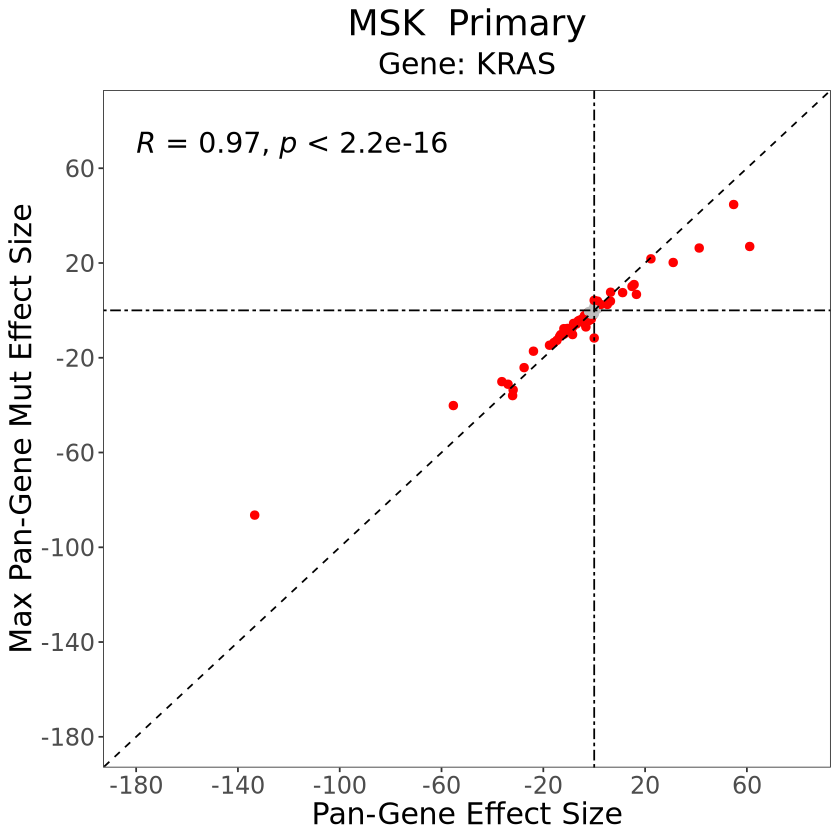

In [86]:
p1

In [87]:
df %>% filter(sign_run!=0)

gene,KRAS_nES,KRAS_G12_nES,KRAS_G13_nES,KRAS_Q61_nES,KRAS_A146_nES,KRAS_K117_nES,type,type_1,type_2,type_3,type_4,type_5,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR,sign_run
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>
AKT1,-2.2454316,-4.3535587,0.0000000,0.5904648,0.00000000,-0.007593325,ME,ME,ME,CO,ME,ME,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,2
AMER1,31.0439365,20.2147188,5.8472581,0.0000000,0.99720941,0.236028485,CO,CO,CO,ME,CO,CO,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,3
APC,61.1097109,26.9730446,19.2710016,0.0000000,9.40113379,0.877646962,CO,CO,CO,ME,CO,CO,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE,4
ARID1A,6.4401614,0.0000000,7.6616096,0.0000000,0.00000000,-0.392074995,CO,ME,CO,ME,ME,ME,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE,2
ARID5B,-2.7490702,-1.4522325,0.0000000,-0.1258062,-0.30071929,0.139091916,ME,ME,ME,ME,ME,CO,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,1
ATM,14.8681548,10.1012609,2.7639879,-1.2364107,0.00000000,0.000000000,CO,CO,CO,ME,ME,ME,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,3
ATRX,-5.6237775,-4.0923000,-0.3930105,0.0000000,0.00000000,0.000000000,ME,ME,ME,ME,ME,ME,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,2
BAP1,-11.8327494,-10.0071840,0.0000000,0.0000000,-0.13001000,0.000000000,ME,ME,ME,ME,ME,ME,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,2
BARD1,-1.4355728,-2.1597554,0.0000000,0.0000000,0.00000000,0.213073380,ME,ME,ME,ME,ME,CO,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,1


In [88]:
temp <-df %>% filter(sign_run!=0)

In [89]:
head(temp[14:19])

,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR
,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE
2,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE
3,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE
4,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE
5,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE
6,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE


In [90]:
mat<-temp[c(8:13)]

In [91]:
mat[(temp[,c(14:19)]==FALSE)]<-''

In [92]:
rownames(mat)<-temp$gene

In [93]:
colnames(mat)<-c('KRAS','KRAS_G12','KRAS_G13','KRAS_Q61','KRAS_A146','KRAS_K117')

In [94]:
mat

,KRAS,KRAS_G12,KRAS_G13,KRAS_Q61,KRAS_A146,KRAS_K117
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AKT1,ME,ME,,,,
AMER1,CO,CO,CO,,,
APC,CO,CO,CO,,CO,
ARID1A,CO,,CO,,,
ARID5B,ME,,,,,
ATM,CO,CO,CO,,,
ATRX,ME,ME,,,,
BAP1,ME,ME,,,,
BARD1,,ME,,,,


In [95]:
df <- reshape2::melt(data=as.matrix(mat))
colnames(df) <- c("x", "y", "value")

In [96]:
df

x,y,value
<fct>,<fct>,<chr>
AKT1,KRAS,ME
AMER1,KRAS,CO
APC,KRAS,CO
ARID1A,KRAS,CO
ARID5B,KRAS,ME
ATM,KRAS,CO
ATRX,KRAS,ME
BAP1,KRAS,ME
BARD1,KRAS,


In [97]:
options(repr.plot.width = 7, repr.plot.height = 15)
p<-ggplot(df, aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

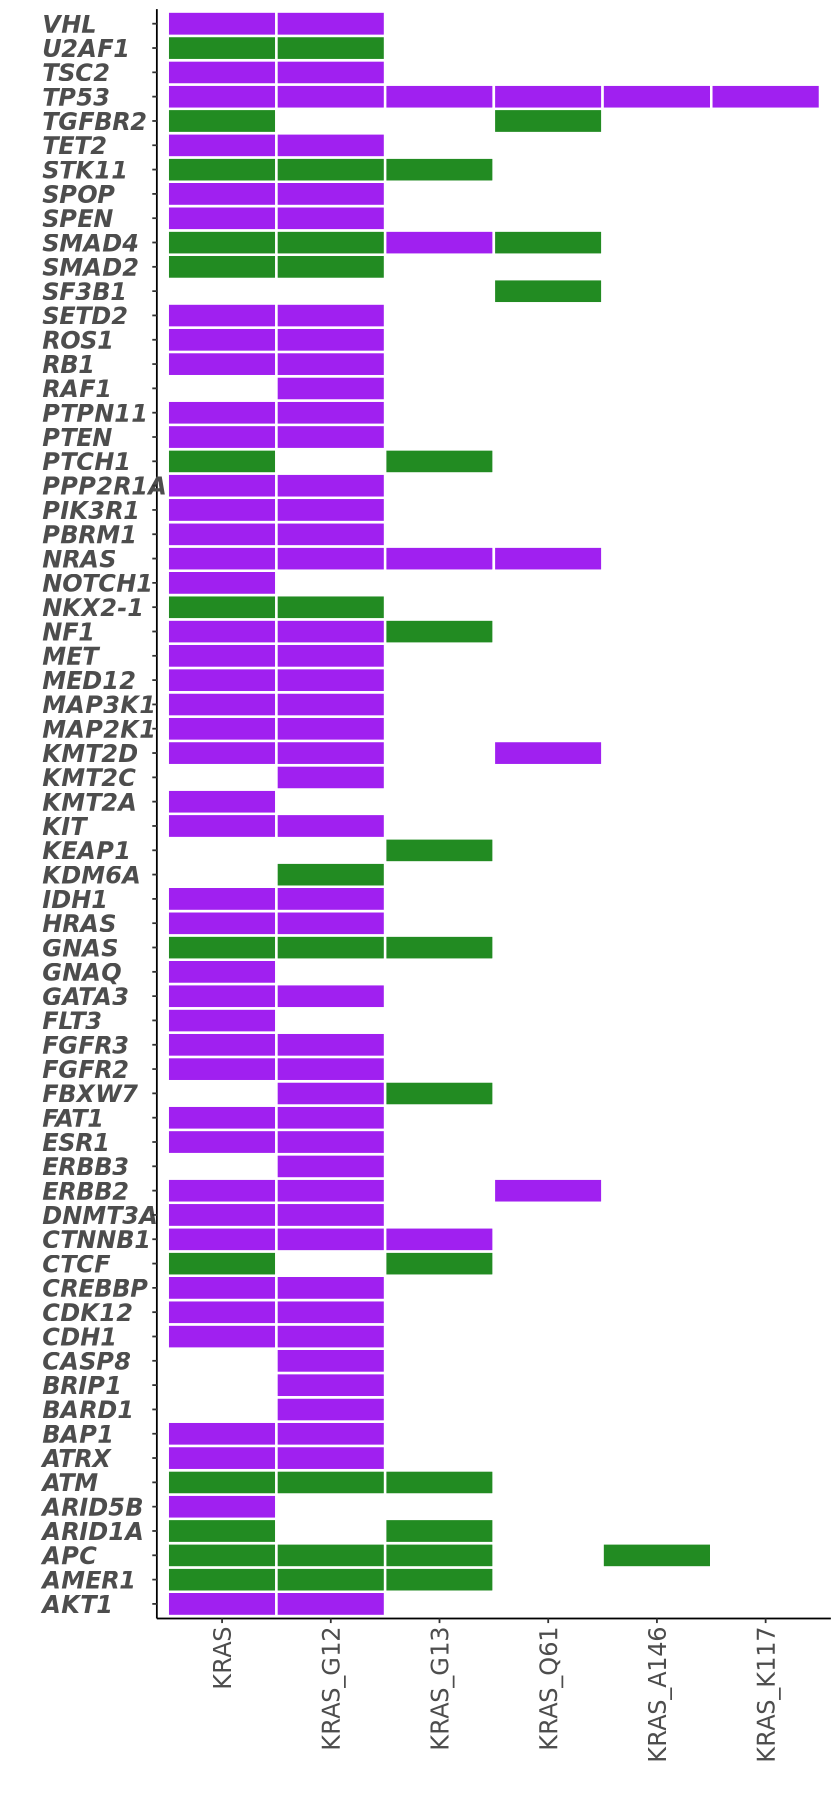

In [98]:
p

In [99]:
kras_df<- df

In [100]:
kras_effect<-temp

## BRAF Specific Analysis

In [102]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='BRAF' | SFE_2=='BRAF'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='BRAF' | SFE_2=='BRAF'))$SFE_2))

In [103]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('BRAF',SFE_1) | grepl('BRAF',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('BRAF',SFE_1) | grepl('BRAF',SFE_2)))$SFE_2))

In [104]:
head(g1)

[1] "BRAF"  "APC"   "AKT1"  "BCOR"  "AMER1" "ASXL1"

In [105]:
head(g2)

[1] "BRAF_1" "APC"    "BRAF_3" "BRAF_2" "AKT1"   "AMER1"

In [106]:
g2[grepl('BRAF',g2)]

[1] "BRAF_1" "BRAF_3" "BRAF_2"

In [108]:
kras <- (msk_p_missense_result %>% filter(SFE_1=='BRAF' | SFE_2=='BRAF') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [109]:
dim(kras)

[1] 188  22

In [110]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='BRAF' | SFE_2=='BRAF'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='BRAF' | SFE_2=='BRAF'))$SFE_2))

In [111]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('BRAF',SFE_1) | grepl('BRAF',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('BRAF',SFE_1) | grepl('BRAF',SFE_2)))$SFE_2))

In [112]:
g <- intersect(g1,g2)

In [113]:
kras_spec_1 <- (msk_p_hotspot_result %>% filter(SFE_1=='BRAF_1' | SFE_2=='BRAF_1') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_2 <- (msk_p_hotspot_result %>% filter(SFE_1=='BRAF_2' | SFE_2=='BRAF_2') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_3 <- (msk_p_hotspot_result %>% filter(SFE_1=='BRAF_3' | SFE_2=='BRAF_3') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [114]:
kras_spec_1<-kras_spec_1 %>% mutate(GENE= case_when(SFE_1=='BRAF_1' ~ SFE_2,SFE_2=='BRAF_1'  ~ SFE_1))
kras_spec_2<-kras_spec_2 %>% mutate(GENE= case_when(SFE_1=='BRAF_2' ~ SFE_2,SFE_2=='BRAF_2'  ~ SFE_1))
kras_spec_3<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='BRAF_3' ~ SFE_2,SFE_2=='BRAF_3'  ~ SFE_1))

In [115]:
dim(kras_spec_1)
dim(kras_spec_2)
dim(kras_spec_3)

[1] 188  23

[1] 188  23

[1] 188  23

In [127]:
head(kras_spec_1)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR,GENE,Fdr
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<chr>,<chr>
ABL1 - BRAF_1,ABL1,BRAF_1,ABL1 - BRAF_1,136,728,0.004887691,0.02616352,12,3.325690,63,⋯,1.00000000,0.0000000,0.6116419,1.00000000,864,1.000000000,ME,FALSE,ABL1,NO
AKT1 - BRAF_1,AKT1,BRAF_1,AKT1 - BRAF_1,365,728,0.013117700,0.02616352,39,21.292000,97,⋯,0.08972548,7.4602802,1.4011849,0.03251952,1093,0.004825538,CO,TRUE,AKT1,YES
AKT2 - BRAF_1,AKT2,BRAF_1,AKT2 - BRAF_1,31,728,0.001114106,0.02616352,4,1.256326,13,⋯,1.00000000,0.0000000,0.4432481,1.00000000,759,1.000000000,ME,FALSE,AKT2,NO
AKT3 - BRAF_1,AKT3,BRAF_1,AKT3 - BRAF_1,62,728,0.002228212,0.02616352,4,1.696791,31,⋯,1.00000000,0.0000000,0.4126900,1.00000000,790,1.000000000,ME,FALSE,AKT3,NO
ALK - BRAF_1,ALK,BRAF_1,ALK - BRAF_1,207,728,0.007439353,0.02616352,16,4.332840,91,⋯,1.00000000,-0.1278724,-0.9926766,1.00000000,935,1.000000000,ME,FALSE,ALK,NO
AMER1 - BRAF_1,AMER1,BRAF_1,AMER1 - BRAF_1,363,728,0.013045822,0.02616352,23,6.009492,295,⋯,0.22550111,-3.6318426,-1.3620307,0.11463659,1091,0.051628417,ME,TRUE,AMER1,YES


In [116]:
kras<-kras %>% mutate(GENE= case_when(SFE_1!='BRAF' ~ SFE_1,
                        SFE_1=='BRAF'  ~ SFE_2))

kras<-kras %>% arrange(GENE)
kras_spec_1<-kras_spec_1 %>% arrange(GENE)
kras_spec_2<-kras_spec_2 %>% arrange(GENE)
kras_spec_3<-kras_spec_3 %>% arrange(GENE)

In [117]:
kras$Fdr<-'NO'
kras[(kras %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_1$Fdr<-'NO'
kras_spec_1[(kras_spec_1 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_2$Fdr<-'NO'
kras_spec_2[(kras_spec_2 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_3$Fdr<-'NO'
kras_spec_3[(kras_spec_3 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

In [128]:
df <- data.frame('gene'=kras_spec_1$GENE,
                'BRAF_nES'=kras$nES,
                'BRAF_1_nES'=kras_spec_1$nES,
                'BRAF_2_nES'=kras_spec_2$nES,
                'BRAF_3_nES'=kras_spec_3$nES,
                'type'=kras$type,
                'type_1'=kras_spec_1$type,
                'type_2'=kras_spec_2$type,
                'type_3'=kras_spec_3$type,
                'type_FDR'=kras$FDR,
                'type_1_FDR'=kras_spec_1$FDR,
                'type_2_FDR'=kras_spec_2$FDR,
                'type_3_FDR'=kras_spec_3$FDR
                )

In [129]:
head(df,2)

,gene,BRAF_nES,BRAF_1_nES,BRAF_2_nES,BRAF_3_nES,type,type_1,type_2,type_3,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
1,ABL1,0.000000,0.00000,0.0000000,0.08435535,ME,ME,ME,CO,FALSE,FALSE,FALSE,FALSE
2,AKT1,6.288101,7.46028,-0.1903418,0.00000000,CO,CO,ME,ME,TRUE,TRUE,FALSE,FALSE


In [131]:
mat<-(df[,c(3:5)])
row.names(mat)<-df$gene

In [132]:
scatter_df <- data.frame('gene'=df$gene)
scatter_df$pan_gene_nES<-df$BRAF_nES

In [133]:
scatter_df$best_mut_nES<-mat[cbind(1:nrow(mat), max.col(abs(mat)))]
scatter_df$label<-(mat %>%
  mutate(Class = names(.)[max.col(.)]))$Class

In [134]:
df$sign_run <- rowSums(df[,c(10:13)])

In [135]:
scatter_df$sign_run<-as.factor(df$sign_run)

In [136]:
head(scatter_df)

,gene,pan_gene_nES,best_mut_nES,label,sign_run
,<chr>,<dbl>,<dbl>,<chr>,<fct>
1,ABL1,0.0000000,0.08435535,BRAF_3_nES,0
2,AKT1,6.2881011,7.46028021,BRAF_1_nES,2
3,AKT2,0.0000000,0.00000000,BRAF_2_nES,0
4,AKT3,0.0000000,0.00000000,BRAF_2_nES,0
5,ALK,-0.3745168,-0.16219616,BRAF_2_nES,0
6,AMER1,-3.5015301,-3.63184264,BRAF_3_nES,2


In [143]:
options(repr.plot.width = 7, repr.plot.height = 7)
options(ggrepel.max.overlaps = 100)
#p1<-
p2<-ggscatter(scatter_df,
          x='pan_gene_nES',
          y='best_mut_nES',
          color='sign_run',
          fill='sign_run',
          palette= c("grey","red", "red", "red","red"),
          repel = TRUE,
          #label='gene',
          #label.select= c('NF1','SAMD4'),
          font.label = c(10, "bold"))+
          theme_bw()+stat_cor(size=6)+
#         ggrepel::geom_text_repel(
#                 data = (scatter_df %>% filter(gene %in% ('NF1','SMAD4','KEA'))),
#                 aes(label = gene),
#                 size = 4,
#                 box.padding = unit(0.7, "lines"),
#                 point.padding = unit(0.7, "lines"))+
geom_hline(yintercept = 0,linetype=6)+
geom_vline(xintercept = 0,linetype=6)+
geom_abline(slope = 1,intercept = 0,linetype=2)+
ggtitle('MSK  Primary')+labs(subtitle = 'Gene: BRAF')+
theme_bw()+
xlab('Pan-Gene Effect Size')+
ylab('Max Pan-Gene Mut Effect Size')+
scale_x_continuous(breaks = seq(from = -80, to = 30, by = 10),limits = c(-80, 30))+
scale_y_continuous(breaks = seq(from = -80, to = 30 , by = 10),limits = c(-80, 30))+
theme(plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      text = element_text(size = 18),
      legend.position = 'none',
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.title = element_blank())

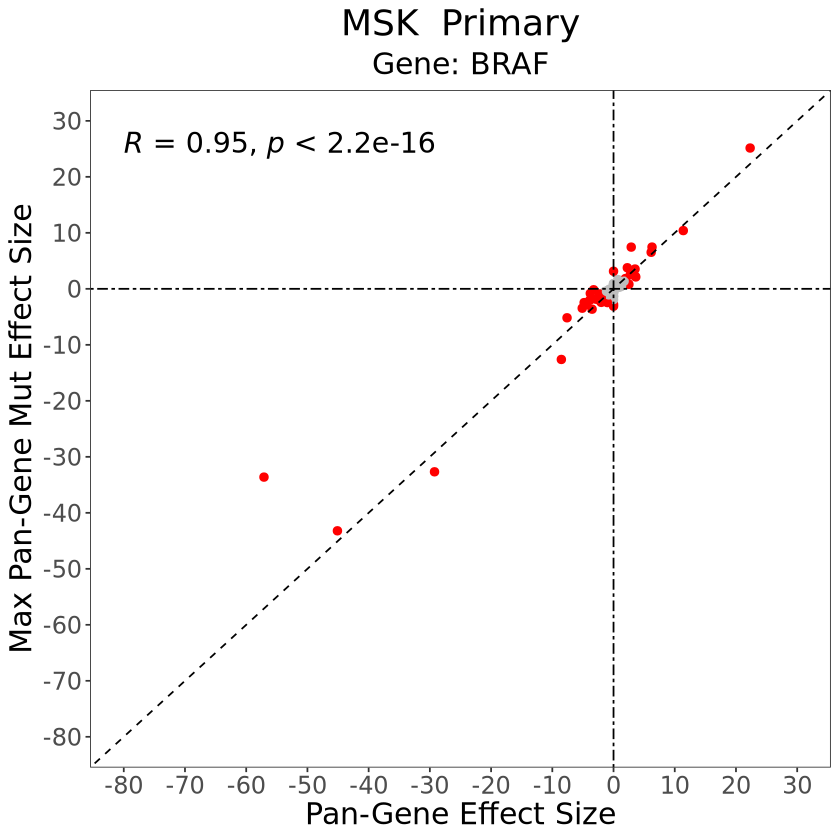

In [144]:
p2

In [145]:
temp <-df %>% filter(sign_run!=0)

In [146]:
mat<-temp[c(6:9)]
mat[(temp[,c(10:13)]==FALSE)]<-''
rownames(mat)<-temp$gene
colnames(mat)<-c('BRAF','BRAF_1','BRAF_2','BRAF_3')

In [148]:
df <- reshape2::melt(data=as.matrix(mat))
colnames(df) <- c("x", "y", "value")

In [149]:
options(repr.plot.width = 7, repr.plot.height = 9)
p<-ggplot(df, aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

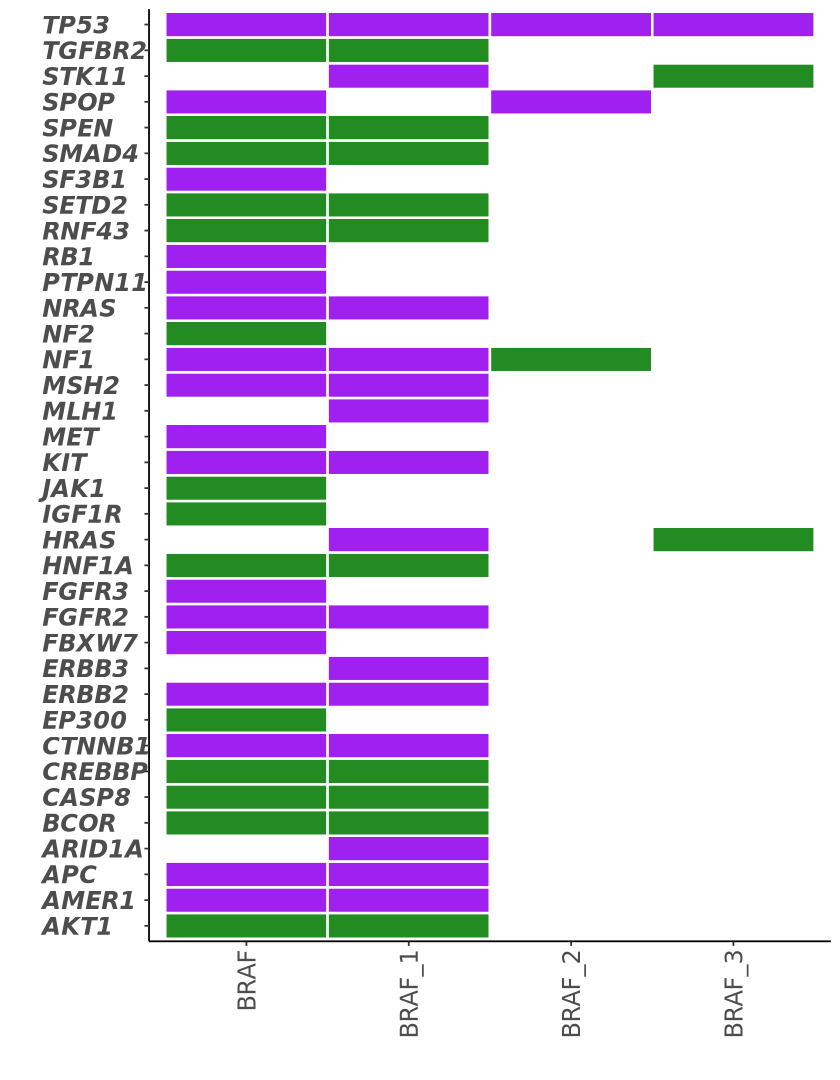

In [150]:
p

In [151]:
braf_df<- df

In [152]:
braf_effect<-temp

## EGFR Specific Analysis

In [153]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='EGFR' | SFE_2=='EGFR'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='EGFR' | SFE_2=='EGFR'))$SFE_2))

In [154]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('EGFR',SFE_1) | grepl('EGFR',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('EGFR',SFE_1) | grepl('EGFR',SFE_2)))$SFE_2))

In [155]:
head(g1)

[1] "EGFR"   "ARID1A" "BRAF"   "ATM"    "APC"    "ATRX"

In [156]:
head(g2)

[1] "EGFR_3" "EGFR_2" "EGFR_1" "ATM"    "ATRX"   "ARID1A"

In [157]:
g2[grepl('EGFR',g2)]

[1] "EGFR_3"    "EGFR_2"    "EGFR_1"    "EGFR_R108" "EGFR_G598"

In [159]:
kras <- (msk_p_missense_result %>% filter(SFE_1=='EGFR' | SFE_2=='EGFR') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [251]:
dim(kras)

[1] 209  21

In [160]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='EGFR' | SFE_2=='EGFR'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='EGFR' | SFE_2=='EGFR'))$SFE_2))

In [161]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('EGFR',SFE_1) | grepl('EGFR',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('EGFR',SFE_1) | grepl('EGFR',SFE_2)))$SFE_2))

In [162]:
g <- intersect(g1,g2)

In [164]:
kras_spec_1 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_1' | SFE_2=='EGFR_1') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_2 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_2' | SFE_2=='EGFR_2') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_3 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_3' | SFE_2=='EGFR_3') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_4 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_R108' | SFE_2=='EGFR_R108') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_5 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_G598' | SFE_2=='EGFR_G598') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [165]:
kras_spec_1<-kras_spec_1 %>% mutate(GENE= case_when(SFE_1=='EGFR_1' ~ SFE_2,SFE_2=='EGFR_1'  ~ SFE_1))
kras_spec_2<-kras_spec_2 %>% mutate(GENE= case_when(SFE_1=='EGFR_2' ~ SFE_2,SFE_2=='EGFR_2'  ~ SFE_1))
kras_spec_3<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='EGFR_3' ~ SFE_2,SFE_2=='EGFR_3'  ~ SFE_1))
kras_spec_4<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='EGFR_R108' ~ SFE_2,SFE_2=='EGFR_R108'  ~ SFE_1))
kras_spec_5<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='EGFR_G598' ~ SFE_2,SFE_2=='EGFR_G598'  ~ SFE_1))

In [166]:
dim(kras_spec_1)
dim(kras_spec_2)
dim(kras_spec_3)
dim(kras_spec_4)
dim(kras_spec_5)

[1] 188  23

[1] 188  23

[1] 188  23

[1] 188  23

[1] 188  23

In [167]:
kras<-kras %>% mutate(GENE= case_when(SFE_1!='EGFR' ~ SFE_1,
                        SFE_1=='EGFR'  ~ SFE_2))

kras<-kras %>% arrange(GENE)
kras_spec_1<-kras_spec_1 %>% arrange(GENE)
kras_spec_2<-kras_spec_2 %>% arrange(GENE)
kras_spec_3<-kras_spec_3 %>% arrange(GENE)
kras_spec_4<-kras_spec_4 %>% arrange(GENE)
kras_spec_5<-kras_spec_5 %>% arrange(GENE)

In [168]:
kras$Fdr<-'NO'
kras[(kras %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_1$Fdr<-'NO'
kras_spec_1[(kras_spec_1 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_2$Fdr<-'NO'
kras_spec_2[(kras_spec_2 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_3$Fdr<-'NO'
kras_spec_3[(kras_spec_3 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_4$Fdr<-'NO'
kras_spec_4[(kras_spec_4 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_5$Fdr<-'NO'
kras_spec_5[(kras_spec_5 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

In [169]:
df <- data.frame('gene'=kras_spec_1$GENE,
                'EGFR_nES'=kras$nES,
                'EGFR_1'=kras_spec_1$nES,
                'EGFR_2'=kras_spec_2$nES,
                'EGFR_3'=kras_spec_3$nES,
                'EGFR_R108'=kras_spec_3$nES,
                'EGFR_G598'=kras_spec_3$nES,
                'type'=kras$type,
                'type_1'=kras_spec_1$type,
                'type_2'=kras_spec_2$type,
                'type_3'=kras_spec_3$type,
                'type_4'=kras_spec_4$type,
                'type_5'=kras_spec_5$type,                 
                'type_FDR'=kras$FDR,
                'type_1_FDR'=kras_spec_1$FDR,
                'type_2_FDR'=kras_spec_2$FDR,
                'type_3_FDR'=kras_spec_3$FDR,
                'type_4_FDR'=kras_spec_4$FDR,
                'type_5_FDR'=kras_spec_5$FDR                 
                )

In [170]:
mat<-(df[,c(3:7)])
rownames(mat)<-df$gene

In [171]:
scatter_df <- data.frame('gene'=df$gene)
scatter_df$pan_gene_nES<-df$EGFR_nES

In [172]:
scatter_df$best_mut_nES<-mat[cbind(1:nrow(mat), max.col(abs(mat)))]
scatter_df$label<-(mat %>%
  mutate(Class = names(.)[max.col(.)]))$Class

In [176]:
df$sign_run <- rowSums(df[,c(15:19)])

In [177]:
scatter_df$sign_run<-as.factor(df$sign_run)

In [178]:
head(scatter_df)

,gene,pan_gene_nES,best_mut_nES,label,sign_run
,<chr>,<dbl>,<dbl>,<chr>,<fct>
1,ABL1,-0.81535797,-0.1986576,EGFR_1,2
2,AKT1,-1.45480984,-0.2696881,EGFR_2,2
3,AKT2,-0.03579115,0.0000000,EGFR_2,2
4,AKT3,0.00000000,0.2234913,EGFR_2,2
5,ALK,-2.25813633,0.0000000,EGFR_G598,2
6,AMER1,-2.36173935,-0.8439177,EGFR_1,2


In [179]:
options(repr.plot.width = 7, repr.plot.height = 7)
options(ggrepel.max.overlaps = 100)
#p1<-
p3<-ggscatter(scatter_df,
          x='pan_gene_nES',
          y='best_mut_nES',
          color='sign_run',
          fill='sign_run',
          palette= c("grey","red", "red", "red","red"),
          repel = TRUE,
          #label='gene',
          #label.select= c('NF1','SAMD4'),
          font.label = c(10, "bold"))+
          theme_bw()+stat_cor(size=6)+
#         ggrepel::geom_text_repel(
#                 data = (scatter_df %>% filter(gene %in% ('NF1','SMAD4','KEA'))),
#                 aes(label = gene),
#                 size = 4,
#                 box.padding = unit(0.7, "lines"),
#                 point.padding = unit(0.7, "lines"))+
geom_hline(yintercept = 0,linetype=6)+
geom_vline(xintercept = 0,linetype=6)+
geom_abline(slope = 1,intercept = 0,linetype=2)+
ggtitle('MSK  Primary')+labs(subtitle = 'Gene: EGFR')+
theme_bw()+
xlab('Pan-Gene Effect Size')+
ylab('Max Pan-Gene Mut Effect Size')+
scale_x_continuous(breaks = seq(from = -70, to = 20, by = 10),limits = c(-70, 20))+
scale_y_continuous(breaks = seq(from = -70, to =20 , by = 10),limits = c(-70, 20))+
theme(plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      text = element_text(size = 18),
      legend.position = 'none',
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.title = element_blank())

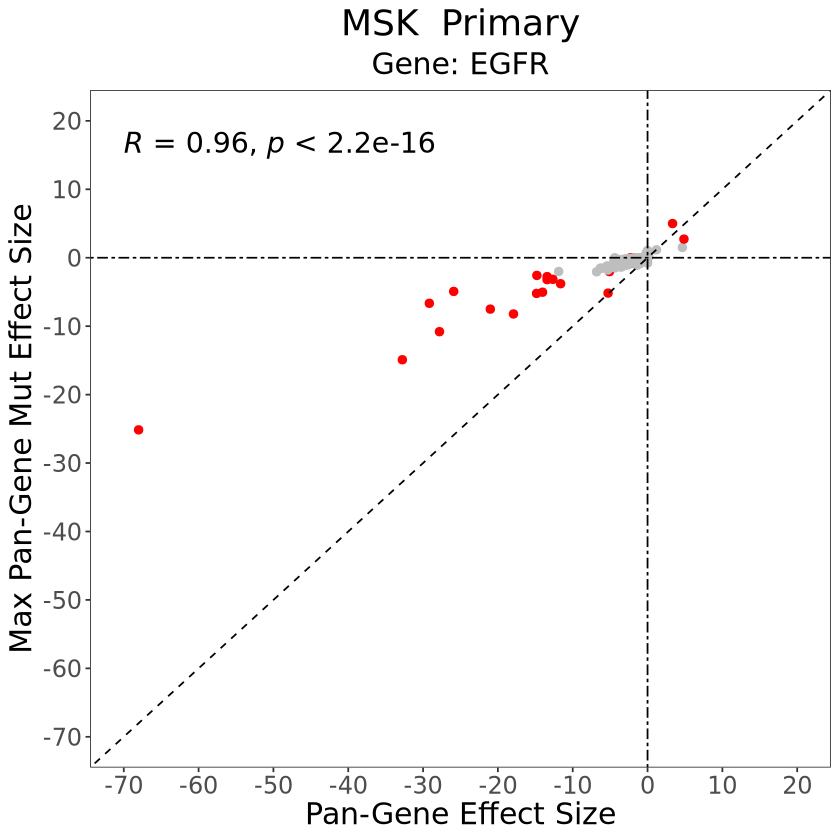

In [180]:
p3

In [181]:
temp <-df %>% filter(sign_run!=0)

In [184]:
temp

gene,EGFR_nES,EGFR_1,EGFR_2,EGFR_3,EGFR_R108,EGFR_G598,type,type_1,type_2,type_3,type_4,type_5,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR,sign_run
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>
ABL1,-0.81535797,0.0000000,-0.06830789,-0.19865764,-0.19865764,-0.19865764,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
AKT1,-1.45480984,-0.2375311,0.00000000,-0.26968811,-0.26968811,-0.26968811,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
AKT2,-0.03579115,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
AKT3,0.00000000,0.0000000,0.22349130,-0.20651211,-0.20651211,-0.20651211,ME,ME,CO,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
ALK,-2.25813633,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,ME,ME,ME,ME,ME,ME,TRUE,FALSE,FALSE,FALSE,TRUE,TRUE,2
AMER1,-2.36173935,0.0000000,-0.01132270,-0.84391767,-0.84391767,-0.84391767,ME,ME,ME,ME,ME,ME,TRUE,FALSE,FALSE,FALSE,TRUE,TRUE,2
APC,-14.79243483,-2.4138521,-0.05218374,-2.58395756,-2.58395756,-2.58395756,ME,ME,ME,ME,ME,ME,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,4
AR,-1.66268997,0.0000000,0.00000000,-0.05338053,-0.05338053,-0.05338053,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
ARAF,-1.03047999,0.0000000,-0.01064956,-0.32610501,-0.32610501,-0.32610501,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2


In [185]:
mat<-temp[c(8:13)]
mat[(temp[,c(14:19)]==FALSE)]<-''
rownames(mat)<-temp$gene
colnames(mat)<-c('EGFR','EGFR_1','EGFR_2','EGFR_3','EGFR_R108','EGFR_G598')

In [187]:
df <- reshape2::melt(data=as.matrix(mat))
colnames(df) <- c("x", "y", "value")

In [188]:
options(repr.plot.width = 7, repr.plot.height = 9)
p<-ggplot(df, aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

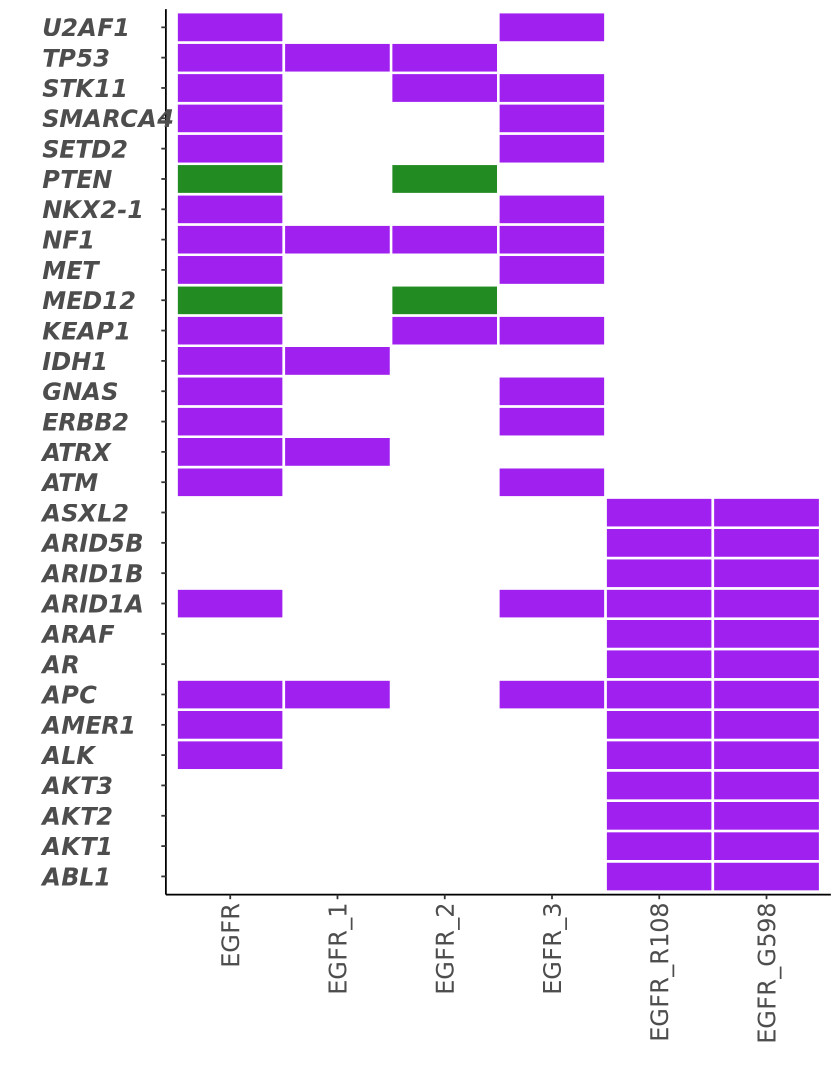

In [189]:
p

In [190]:
egfr_df<- df

In [191]:
egfr_effect<-temp

## PIK3CA Specific Analysis

In [192]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA'))$SFE_2))

In [193]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('PIK3CA',SFE_1) | grepl('PIK3CA',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('PIK3CA',SFE_1) | grepl('PIK3CA',SFE_2)))$SFE_2))

In [194]:
head(g1)

[1] "PIK3CA" "ARID1A" "KRAS"   "MAP3K1" "AKT1"   "CDH1"

In [195]:
head(g2)

[1] "PIK3CA_3" "PIK3CA_5" "PIK3CA_1" "ARID1A"   "PIK3CA_2" "AKT1"

In [196]:
g2[grepl('PIK3CA',g2)]

[1] "PIK3CA_3" "PIK3CA_5" "PIK3CA_1" "PIK3CA_2" "PIK3CA_4"

In [197]:
kras <- (msk_p_missense_result %>% filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [198]:
dim(kras)

[1] 188  22

In [199]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA'))$SFE_2))

In [200]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('PIK3CA',SFE_1) | grepl('PIK3CA',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('PIK3CA',SFE_1) | grepl('PIK3CA',SFE_2)))$SFE_2))

In [201]:
g <- intersect(g1,g2)

In [203]:
kras_spec_1 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_1' | SFE_2=='PIK3CA_1') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_2 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_2' | SFE_2=='PIK3CA_2') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_3 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_3' | SFE_2=='PIK3CA_3') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_4 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_4' | SFE_2=='PIK3CA_4') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_5 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_5' | SFE_2=='PIK3CA_5') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [204]:
kras_spec_1<-kras_spec_1 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_1' ~ SFE_2,SFE_2=='PIK3CA_1'  ~ SFE_1))
kras_spec_2<-kras_spec_2 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_2' ~ SFE_2,SFE_2=='PIK3CA_2'  ~ SFE_1))
kras_spec_3<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_3' ~ SFE_2,SFE_2=='PIK3CA_3'  ~ SFE_1))
kras_spec_4<-kras_spec_4 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_4' ~ SFE_2,SFE_2=='PIK3CA_4'  ~ SFE_1))
kras_spec_5<-kras_spec_5 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_5' ~ SFE_2,SFE_2=='PIK3CA_5'  ~ SFE_1))

In [205]:
dim(kras_spec_1)
dim(kras_spec_2)
dim(kras_spec_3)
dim(kras_spec_4)
dim(kras_spec_5)

[1] 188  23

[1] 188  23

[1] 188  23

[1] 188  23

[1] 188  23

In [206]:
kras<-kras %>% mutate(GENE= case_when(SFE_1!='PIK3CA' ~ SFE_1,
                        SFE_1=='PIK3CA'  ~ SFE_2))

kras<-kras %>% arrange(GENE)
kras_spec_1<-kras_spec_1 %>% arrange(GENE)
kras_spec_2<-kras_spec_2 %>% arrange(GENE)
kras_spec_3<-kras_spec_3 %>% arrange(GENE)
kras_spec_4<-kras_spec_4 %>% arrange(GENE)
kras_spec_5<-kras_spec_5 %>% arrange(GENE)

In [208]:
kras$Fdr<-'NO'
kras[(kras %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_1$Fdr<-'NO'
kras_spec_1[(kras_spec_1 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_2$Fdr<-'NO'
kras_spec_2[(kras_spec_2 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_3$Fdr<-'NO'
kras_spec_3[(kras_spec_3 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_4$Fdr<-'NO'
#kras_spec_4[(kras_spec_4 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_5$Fdr<-'NO'
kras_spec_5[(kras_spec_5 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

In [209]:
df <- data.frame('gene'=kras_spec_1$GENE,
                'PIK3CA_nES'=kras$nES,
                'PIK3CA_1'=kras_spec_1$nES,
                'PIK3CA_2'=kras_spec_2$nES,
                'PIK3CA_3'=kras_spec_3$nES,
                'PIK3CA_4'=kras_spec_4$nES,
                'PIK3CA_5'=kras_spec_5$nES,
                'type'=kras$type,
                'type_1'=kras_spec_1$type,
                'type_2'=kras_spec_2$type,
                'type_3'=kras_spec_3$type,
                'type_4'=kras_spec_4$type,
                'type_5'=kras_spec_5$type,
                'type_FDR'=kras$FDR,
                'type_1_FDR'=kras_spec_1$FDR,
                'type_2_FDR'=kras_spec_2$FDR,
                'type_3_FDR'=kras_spec_3$FDR,
                'type_4_FDR'=kras_spec_4$FDR,
                'type_5_FDR'=kras_spec_5$FDR
                )

In [210]:
mat<-(df[,c(3:7)])
rownames(mat)<-df$gene

In [211]:
scatter_df <- data.frame('gene'=df$gene)
scatter_df$pan_gene_nES<-df$PIK3CA_nES

In [212]:
scatter_df$best_mut_nES<-mat[cbind(1:nrow(mat), max.col(abs(mat)))]
scatter_df$label<-(mat %>%
  mutate(Class = names(.)[max.col(.)]))$Class

In [213]:
df$sign_run <- rowSums(df[,c(14:19)])

In [214]:
scatter_df$sign_run<-as.factor(df$sign_run)

In [215]:
head(scatter_df)

,gene,pan_gene_nES,best_mut_nES,label,sign_run
,<chr>,<dbl>,<dbl>,<chr>,<fct>
1,ABL1,2.4922735,1.5786869,PIK3CA_3,1
2,AKT1,-33.8033994,-17.1685820,PIK3CA_4,4
3,AKT2,0.0000000,-0.2251381,PIK3CA_4,0
4,AKT3,0.0000000,0.4506469,PIK3CA_5,0
5,ALK,-0.4958769,-0.5628624,PIK3CA_4,0
6,AMER1,8.1932904,4.1741544,PIK3CA_3,2


In [229]:
min(scatter_df$pan_gene_nES)

[1] -295.4658

In [232]:
options(repr.plot.width = 7, repr.plot.height = 7)
options(ggrepel.max.overlaps = 100)
#p1<-
p4<-ggscatter(scatter_df,
          x='pan_gene_nES',
          y='best_mut_nES',
          color='sign_run',
          fill='sign_run',
          palette= c("grey","red", "red", "red","red","red"),
          repel = TRUE,
          #label='gene',
          #label.select= c('NF1','SAMD4'),
          font.label = c(10, "bold"))+
          theme_bw()+stat_cor(size=6)+
#         ggrepel::geom_text_repel(
#                 data = (scatter_df %>% filter(gene %in% ('NF1','SMAD4','KEA'))),
#                 aes(label = gene),
#                 size = 4,
#                 box.padding = unit(0.7, "lines"),
#                 point.padding = unit(0.7, "lines"))+
geom_hline(yintercept = 0,linetype=6)+
geom_vline(xintercept = 0,linetype=6)+
geom_abline(slope = 1,intercept = 0,linetype=2)+
ggtitle('MSK  Primary')+labs(subtitle = 'Gene: PIK3CA')+
theme_bw()+
xlab('Pan-Gene Effect Size')+
ylab('Max Pan-Gene Mut Effect Size')+
scale_x_continuous(breaks = seq(from = -300, to = 100, by = 50),limits = c(-300, 100))+
scale_y_continuous(breaks = seq(from = -300, to = 100 , by = 50),limits = c(-300, 100))+
theme(plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      text = element_text(size = 18),
      legend.position = 'none',
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.title = element_blank())

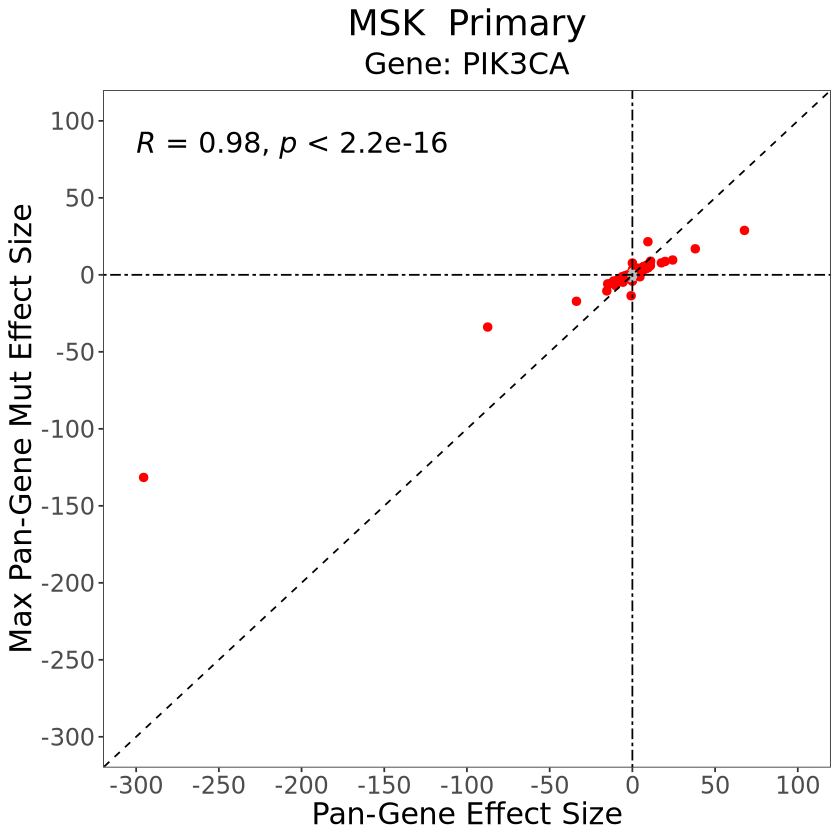

In [233]:
p4

In [234]:
temp <-df %>% filter(sign_run!=0)

In [235]:
mat<-temp[c(8:13)]
mat[(temp[,c(14:19)]==FALSE)]<-''
rownames(mat)<-temp$gene
colnames(mat)<-c('PIK3CA','PIK3CA_1','PIK3CA_2','PIK3CA_3','PIK3CA_4','PIK3CA_5')

In [237]:
df <- reshape2::melt(data=as.matrix(mat))
colnames(df) <- c("x", "y", "value")

In [240]:
options(repr.plot.width = 7, repr.plot.height = 15)
p<-ggplot(df, aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

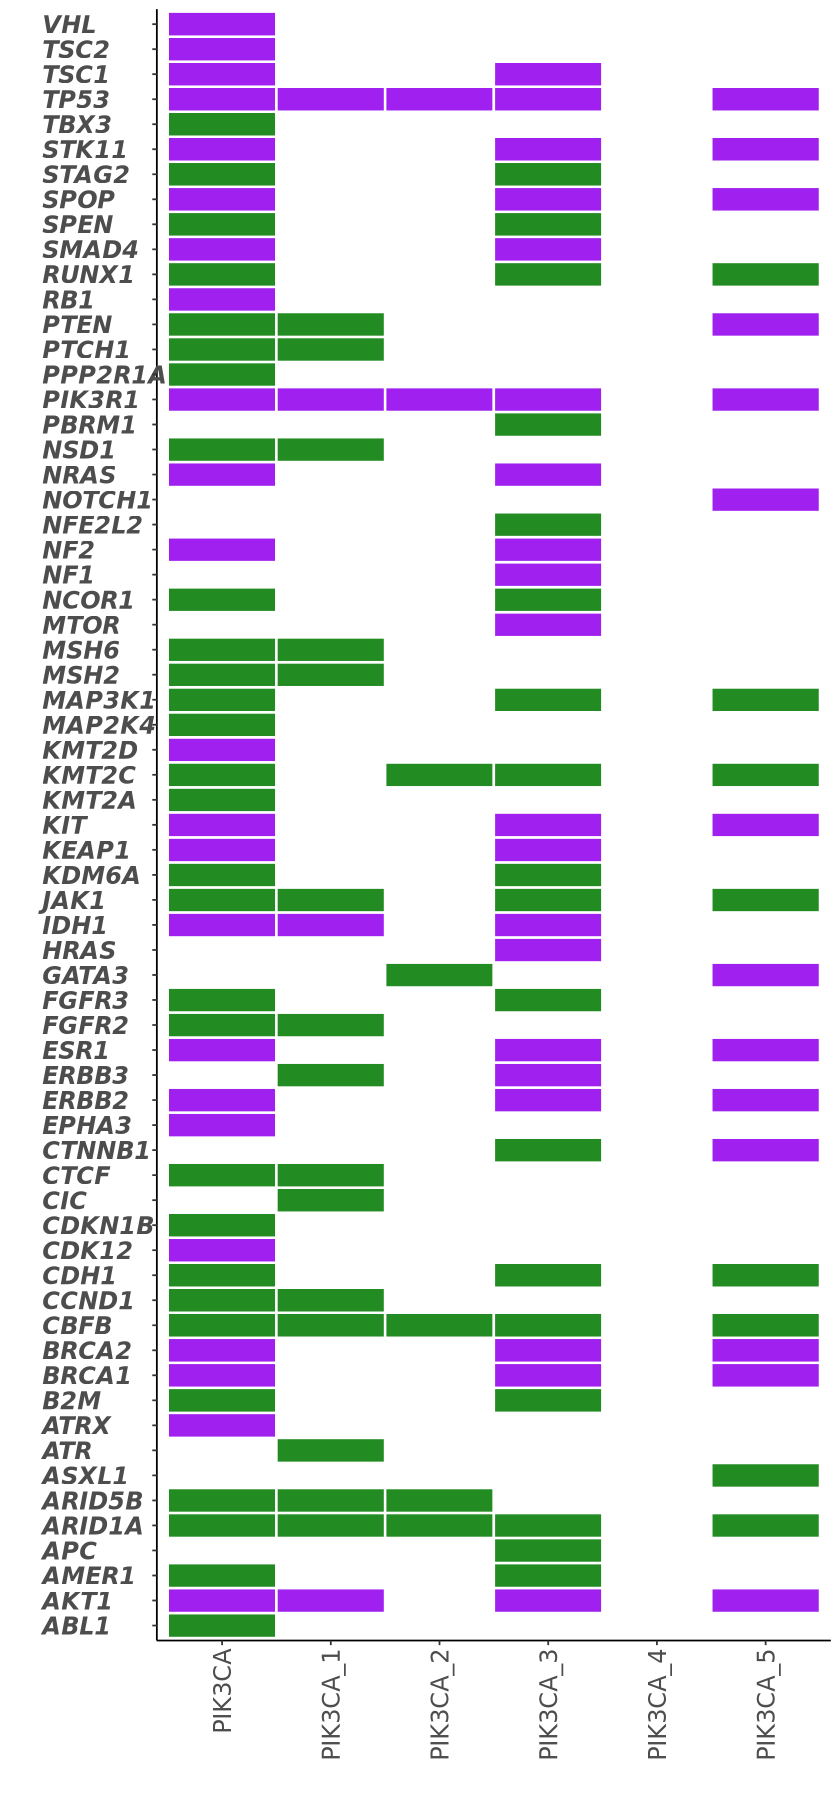

In [241]:
p

In [242]:
pikca_df<-df

In [243]:
pikca_effect<-temp

## Combining Scatter Plot

In [244]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot<-ggarrange(p1,p2,p3,p4,nrow=2,ncol=2)

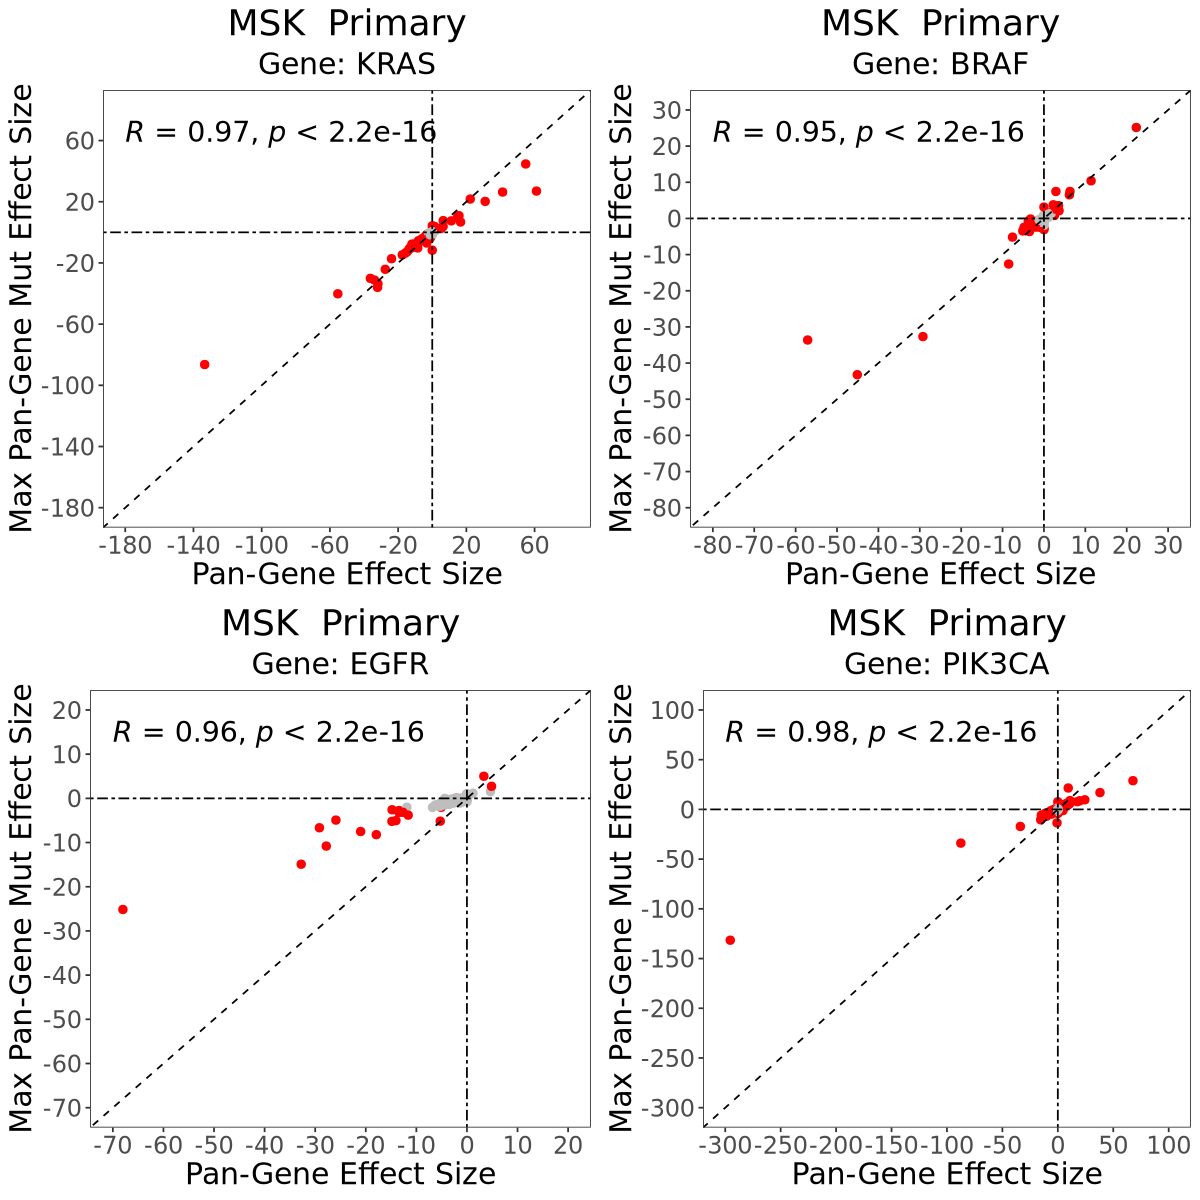

In [245]:
plot

In [247]:
ggsave("../figures/all_panel_msk_hotspot_effect_size_plot.pdf", plot, width = 10, height = 10)

In [248]:
heatmap_df<-bind_rows(kras_df,braf_df,egfr_df,pikca_df)

In [249]:
`%notin%` <- Negate(`%in%`)

In [250]:
head(heatmap_df)

,x,y,value
,<fct>,<fct>,<chr>
1,AKT1,KRAS,ME
2,AMER1,KRAS,CO
3,APC,KRAS,CO
4,ARID1A,KRAS,CO
5,ARID5B,KRAS,ME
6,ATM,KRAS,CO


In [266]:
options(repr.plot.width = 10, repr.plot.height = 25)
p<-ggplot(heatmap_df %>%filter(y %notin% c('PIK3CA_4')), aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

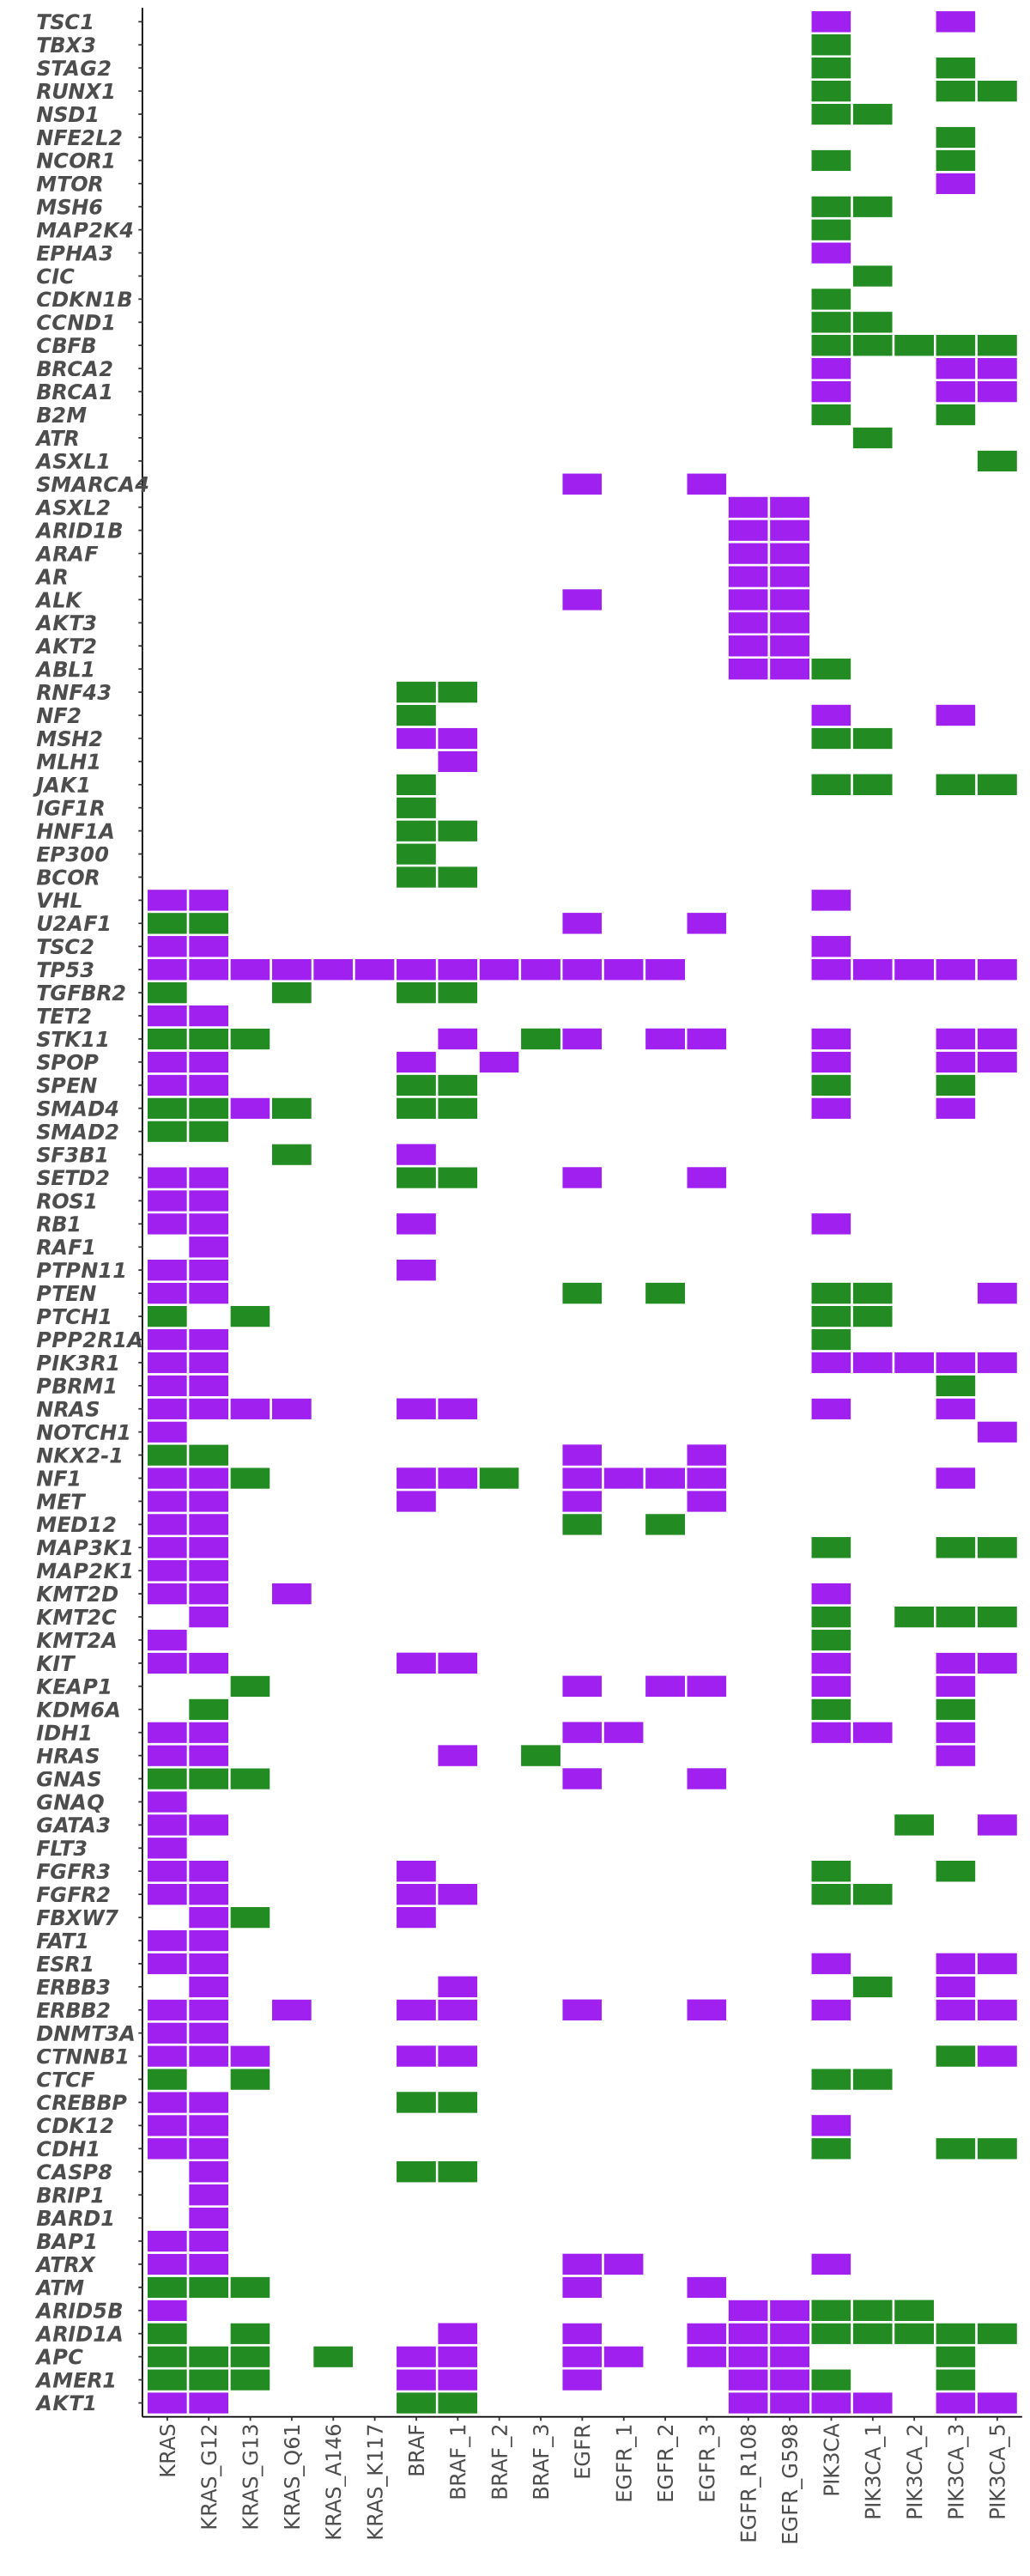

In [267]:
p

In [271]:
plot_genes<-c('FBXW7','KDM6A','KEAP1','NF1','SF3B1','SMAD4','ARID1A','ERBB3','HRAS','STK11','MLH1','AKT1',
'ARID5B','AR','ARAF','SMARCA4','APC','CTNNB1','GATA3','NOTCH1','PBRM1','PTEN','ASXL1','CIC','MTOR')

In [284]:
options(repr.plot.width = 9, repr.plot.height = 9)
p<-ggplot(heatmap_df %>%filter(y %notin% c('PIK3CA_4')) %>% filter(x %in% plot_genes) , aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.9,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'italic',hjust=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))

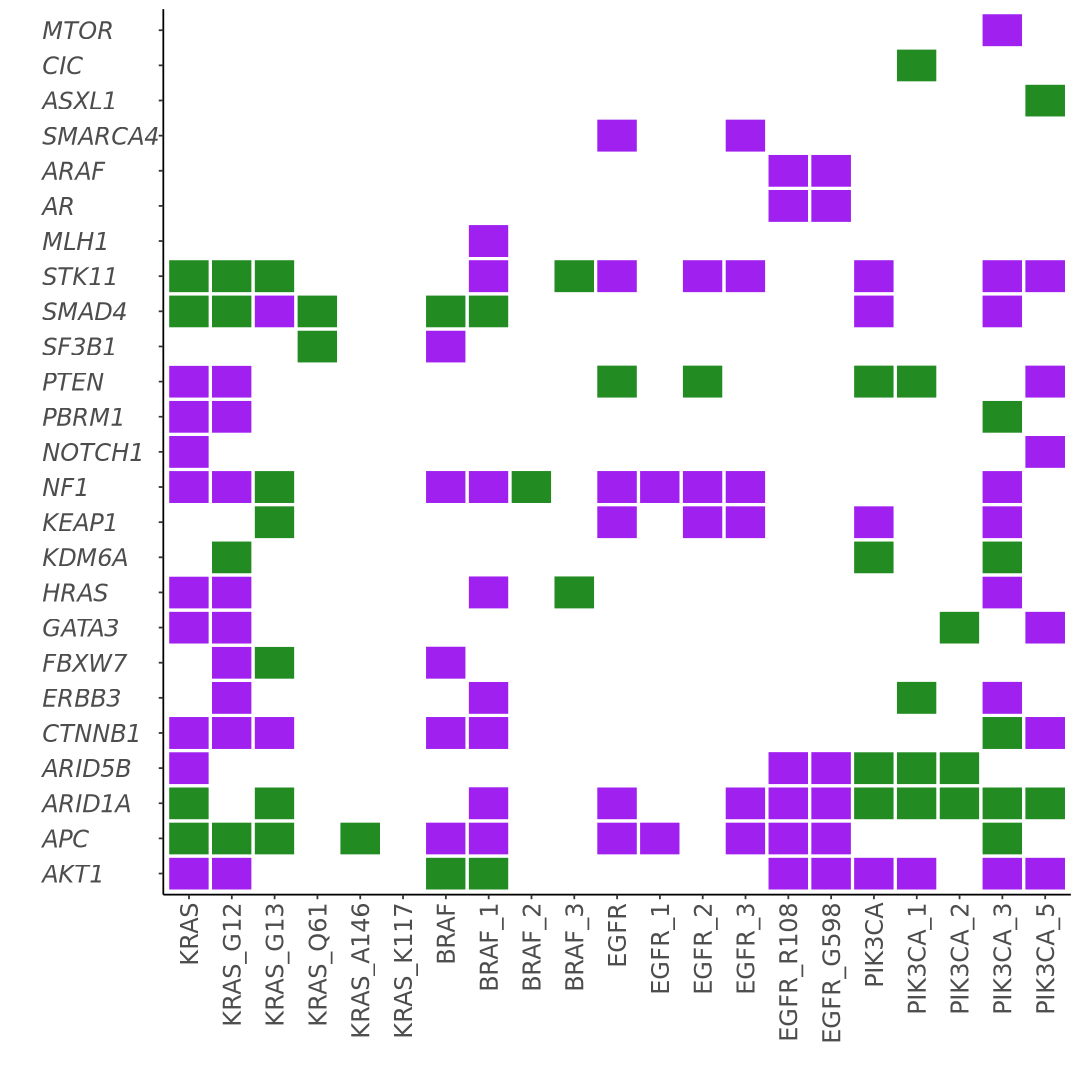

In [285]:
p

In [287]:
ggsave("../figures/hotspot_select_heatmap_plot.pdf", p, width = 9, height = 9)

# Read the results (p468)

In [6]:
msk_p_missense_obj <- readRDS('../../catalogue/results/msk_panel_p_468_primary_result.rds')
msk_p_hotspot_obj <- readRDS('../results/msk_panel_468_primary_hotspot_result.rds')

In [7]:
msk_p_missense_result <- msk_p_missense_obj$result
msk_p_hotspot_result <- msk_p_hotspot_obj$result
rm(msk_p_missense_obj)
rm(msk_p_hotspot_obj)

In [8]:
saveRDS(msk_p_hotspot_result,file='../results/msk_panel_468_primary_hotspot_result_df.rds')

In [3]:
dim(msk_p_missense_result)

[1] 36585    22

In [4]:
dim(msk_p_hotspot_result)

[1] 40470    22

In [5]:
head(msk_p_missense_result)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,w_r_overlap,wES,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
PIK3CA - TP53,PIK3CA,TP53,PIK3CA - TP53,2270,6246,0.16359181,0.4501297,782,585.709143,1852,⋯,890.7328,-215.68427,0,-205.54725,-10.137016,0,8516,0,ME,TRUE
PTEN - TP53,PTEN,TP53,PTEN - TP53,1363,6246,0.09822715,0.4501297,387,260.737675,897,⋯,415.8731,-109.69731,0,-102.23675,-7.460552,0,7609,0,ME,TRUE
EGFR - KRAS,EGFR,KRAS,EGFR - KRAS,626,2899,0.04511387,0.2089219,13,5.543963,498,⋯,148.7460,-101.25910,0,-96.72071,-4.538393,0,3525,0,ME,TRUE
ARID1A - TP53,ARID1A,TP53,ARID1A - TP53,1443,6246,0.10399251,0.4501297,490,308.856028,1049,⋯,453.0415,-101.95455,0,-94.61339,-7.341154,0,7689,0,ME,TRUE
GATA3 - TP53,GATA3,TP53,GATA3 - TP53,284,6246,0.02046699,0.4501297,34,24.939762,284,⋯,125.7199,-71.26231,0,-67.18275,-4.079560,0,6530,0,ME,TRUE
BRAF - KRAS,BRAF,KRAS,BRAF - KRAS,630,2899,0.04540213,0.2089219,43,26.583393,424,⋯,120.4912,-66.40287,0,-61.93563,-4.467234,0,3529,0,ME,TRUE


In [6]:
head(msk_p_hotspot_result)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,w_r_overlap,wES,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
PTEN - TP53,PTEN,TP53,PTEN - TP53,1363,6246,0.09822715,0.4501297,387,260.73768,897,⋯,415.1573,-109.19114,0,-101.46323,-7.727914,0,7609,0,ME,TRUE
ARID1A - TP53,ARID1A,TP53,ARID1A - TP53,1443,6246,0.10399251,0.4501297,490,308.85603,1049,⋯,453.3037,-102.13991,0,-94.95247,-7.187435,0,7689,0,ME,TRUE
PIK3CA_3 - TP53,PIK3CA_3,TP53,PIK3CA_3 - TP53,949,6246,0.06839147,0.4501297,337,259.02715,904,⋯,388.7138,-91.70231,0,-84.80139,-6.900916,0,7195,0,ME,TRUE
PIK3CA_5 - TP53,PIK3CA_5,TP53,PIK3CA_5 - TP53,734,6246,0.05289709,0.4501297,229,169.21230,711,⋯,273.3223,-73.61689,0,-67.77617,-5.840716,0,6980,0,ME,TRUE
GATA3 - TP53,GATA3,TP53,GATA3 - TP53,284,6246,0.02046699,0.4501297,34,24.93976,284,⋯,125.8100,-71.32603,0,-67.23251,-4.093523,0,6530,0,ME,TRUE
APC - TP53,APC,TP53,APC - TP53,1809,6246,0.13036898,0.4501297,1186,981.31451,1705,⋯,891.3130,63.64065,0,55.41118,8.229476,0,8055,0,CO,TRUE


## KRAS Specific Analysis

In [9]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='KRAS' | SFE_2=='KRAS'))$SFE_1,
             (msk_p_missense_result %>%filter(SFE_1=='KRAS' | SFE_2=='KRAS'))$SFE_2))

In [10]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('KRAS',SFE_1) | grepl('KRAS',SFE_2)))$SFE_1,
             (msk_p_hotspot_result %>%filter(grepl('KRAS',SFE_1) | grepl('KRAS',SFE_2)))$SFE_2))

In [11]:
head(g1)

[1] "EGFR"   "BRAF"   "KRAS"   "APC"    "CTNNB1" "ERBB2"

In [12]:
head(g2)

[1] "KRAS_G12" "EGFR_3"   "BRAF_1"   "CTNNB1"   "ERBB2"    "APC"

In [13]:
g2[grepl('KRAS',g2)]

[1] "KRAS_G12"  "KRAS_A146" "KRAS_G13"  "KRAS_Q61"  "KRAS_A59"

In [14]:
g <- intersect(g1,g2)

In [15]:
length(g)

[1] 267

In [16]:
kras <- (msk_p_missense_result %>% filter(SFE_1=='KRAS' | SFE_2=='KRAS') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [17]:
dim(kras)

[1] 267  22

In [18]:
kras_spec_1 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_G12' | SFE_2=='KRAS_G12') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_2 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_G13' | SFE_2=='KRAS_G13') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_3 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_Q61' | SFE_2=='KRAS_Q61') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_4 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_A146' | SFE_2=='KRAS_A146') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_5 <- (msk_p_hotspot_result %>% filter(SFE_1=='KRAS_A59' | SFE_2=='KRAS_A59') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
#kras_spec_6 <- (msk_p_mut %>% filter(SFE_1=='KRAS_V14' | SFE_2=='KRAS_V14') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
#kras_spec_7 <- (msk_p_mut %>% filter(SFE_1=='KRAS_A59' | SFE_2=='KRAS_A59') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [20]:
kras_spec_1<-kras_spec_1 %>% mutate(GENE= case_when(SFE_1=='KRAS_G12' ~ SFE_2,SFE_2=='KRAS_G12'  ~ SFE_1))
kras_spec_2<-kras_spec_2 %>% mutate(GENE= case_when(SFE_1=='KRAS_G13' ~ SFE_2,SFE_2=='KRAS_G13'  ~ SFE_1))
kras_spec_3<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='KRAS_Q61' ~ SFE_2,SFE_2=='KRAS_Q61'  ~ SFE_1))
kras_spec_4<-kras_spec_4 %>% mutate(GENE= case_when(SFE_1=='KRAS_A146' ~ SFE_2,SFE_2=='KRAS_A146'  ~ SFE_1))
kras_spec_5<-kras_spec_5 %>% mutate(GENE= case_when(SFE_1=='KRAS_A59' ~ SFE_2,SFE_2=='KRAS_A59'  ~ SFE_1))
#kras_spec_6<-kras_spec_5 %>% mutate(GENE= case_when(SFE_1=='KRAS_V14' ~ SFE_2,SFE_2=='KRAS_V14'  ~ SFE_1))
#kras_spec_7<-kras_spec_5 %>% mutate(GENE= case_when(SFE_1=='KRAS_A59' ~ SFE_2,SFE_2=='KRAS_A59'  ~ SFE_1))

In [21]:
dim(kras_spec_1)
dim(kras_spec_2)
dim(kras_spec_3)
dim(kras_spec_4)
dim(kras_spec_5)
#dim(kras_spec_6)
#dim(kras_spec_7)

[1] 267  23

[1] 267  23

[1] 267  23

[1] 267  23

[1] 267  23

In [22]:
dim(kras)

[1] 267  22

In [23]:
head(kras,5)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,w_r_overlap,wES,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
KRAS - TP53,KRAS,TP53,KRAS - TP53,2899,6246,0.2089219,0.45012972,1472,1282.17785,2576,⋯,1381.96807,-70.56234,0.0000000000,-59.41653,-11.145810,0.0000000000,9145,0.0000000000,ME,TRUE
APC - KRAS,APC,KRAS,APC - KRAS,1809,2899,0.1303690,0.20892188,763,591.51269,1130,⋯,535.75565,39.42618,0.0003716091,31.61857,7.807609,0.0001858045,4708,0.0002090301,CO,TRUE
KRAS - NRAS,KRAS,NRAS,KRAS - NRAS,2899,253,0.2089219,0.01823292,12,7.51137,164,⋯,54.38907,-33.14754,0.0014492754,-30.17013,-2.977412,0.0002229654,3152,0.0002623123,ME,TRUE
KRAS - SMAD4,KRAS,SMAD4,KRAS - SMAD4,2899,503,0.2089219,0.03624964,280,247.30876,480,⋯,204.42246,30.32519,0.0023690078,24.93494,5.390245,0.0005972289,3402,0.0007270612,CO,TRUE
KRAS - STK11,KRAS,STK11,KRAS - STK11,2899,297,0.2089219,0.02140386,146,117.77444,293,⋯,81.94818,25.33299,0.0044283414,21.92764,3.405352,0.0011457946,3196,0.0013749535,CO,TRUE


In [24]:
head(kras_spec_1)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,wES,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR,GENE
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
KRAS_G12 - TP53,KRAS_G12,TP53,KRAS_G12 - TP53,2292,6246,0.16517728,0.45012972,1174,1050.74186,2128,⋯,-48.11380,0.000000000,-37.56111,-10.552690,0.0000000000,8538,0.000000000,ME,TRUE,TP53
KRAS_G12 - NRAS,KRAS_G12,NRAS,KRAS_G12 - NRAS,2292,253,0.16517728,0.01823292,8,5.58410,156,⋯,-24.42506,0.003535595,-21.58368,-2.841382,0.0008361204,2545,0.000000000,ME,TRUE,NRAS
KRAS_G12 - SMAD4,KRAS_G12,SMAD4,KRAS_G12 - SMAD4,2292,503,0.16517728,0.03624964,228,208.86425,471,⋯,26.48152,0.002415459,21.03997,5.441543,0.0009180930,2795,0.001300632,CO,TRUE,SMAD4
KRAS_G12 - NF1,KRAS_G12,NF1,KRAS_G12 - NF1,2292,543,0.16517728,0.03913231,27,16.84179,270,⋯,-21.05624,0.005549901,-18.09551,-2.960737,0.0016987843,2835,0.002460308,ME,TRUE,NF1
KRAS_G12 - PTEN,KRAS_G12,PTEN,KRAS_G12 - PTEN,2292,1363,0.16517728,0.09822715,159,106.29346,395,⋯,-23.15708,0.004308656,-17.92046,-5.236626,0.0017629826,3655,0.002526942,ME,TRUE,PTEN
CTNNB1 - KRAS_G12,CTNNB1,KRAS_G12,CTNNB1 - KRAS_G12,466,2292,0.03358317,0.16517728,63,47.77298,367,⋯,-19.78892,0.006863838,-16.24932,-3.539602,0.0022296544,2758,0.000159261,ME,TRUE,CTNNB1


In [25]:
kras<-kras %>% mutate(GENE= case_when(SFE_1!='KRAS' ~ SFE_1,
                        SFE_1=='KRAS'  ~ SFE_2))

In [26]:
kras<-kras %>% arrange(GENE)
kras_spec_1<-kras_spec_1 %>% arrange(GENE)
kras_spec_2<-kras_spec_2 %>% arrange(GENE)
kras_spec_3<-kras_spec_3 %>% arrange(GENE)
kras_spec_4<-kras_spec_4 %>% arrange(GENE)
kras_spec_5<-kras_spec_5 %>% arrange(GENE)
#kras_spec_6<-kras_spec_6 %>% arrange(GENE)
#kras_spec_7<-kras_spec_7 %>% arrange(GENE)

In [28]:
kras$Fdr<-'NO'
kras[(kras %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_1$Fdr<-'NO'
kras_spec_1[(kras_spec_1 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_2$Fdr<-'NO'
kras_spec_2[(kras_spec_2 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_3$Fdr<-'NO'
kras_spec_3[(kras_spec_3 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_4$Fdr<-'NO'
kras_spec_4[(kras_spec_4 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_5$Fdr<-'NO'
#kras_spec_5[(kras_spec_5 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

#kras_spec_6$Fdr<-'NO'

#kras_spec_7$Fdr<-'NO'

In [29]:
df <- data.frame('gene'=kras_spec_1$GENE,
                'KRAS_nES'=kras$nES,
                'KRAS_G12_nES'=kras_spec_1$nES,
                'KRAS_G13_nES'=kras_spec_2$nES,
                'KRAS_Q61_nES'=kras_spec_3$nES,
                'KRAS_A146_nES'=kras_spec_4$nES,
                'KRAS_A59_nES'=kras_spec_5$nES,
                #'KRAS_V14'=kras_spec_6$nES,
                #'KRAS_A59'=kras_spec_7$nES,
                'type'=kras$type,
                'type_1'=kras_spec_1$type,
                'type_2'=kras_spec_2$type,
                'type_3'=kras_spec_3$type,
                'type_4'=kras_spec_4$type,
                'type_5'=kras_spec_5$type,
                #'type_6'=kras_spec_6$type,
                #'type_7'=kras_spec_7$type,
                'type_FDR'=kras$FDR,
                'type_1_FDR'=kras_spec_1$FDR,
                'type_2_FDR'=kras_spec_2$FDR,
                'type_3_FDR'=kras_spec_3$FDR,
                'type_4_FDR'=kras_spec_4$FDR,
                'type_5_FDR'=kras_spec_5$FDR
                #'type_6_FDR'=kras_spec_6$FDR,
                #'type_7_FDR'=kras_spec_7$FDR
                )

In [30]:
head(df)

,gene,KRAS_nES,KRAS_G12_nES,KRAS_G13_nES,KRAS_Q61_nES,KRAS_A146_nES,KRAS_A59_nES,type,type_1,type_2,type_3,type_4,type_5,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,ABL1,0.0000000,0.0000000,0.00000000,-0.002215745,0.0000000,0.09681746,ME,ME,ME,ME,ME,CO,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
2,ACVR1,-0.3580385,-0.1227511,0.00000000,0.000000000,0.0203372,0.00000000,ME,ME,ME,ME,CO,ME,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
3,AKT1,-0.7061792,-1.9080421,-0.20128481,0.906460158,0.0000000,0.00000000,ME,ME,ME,CO,ME,ME,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
4,AKT2,0.0000000,0.0000000,0.05213093,0.000000000,0.0000000,0.00000000,ME,ME,CO,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
5,AKT3,0.0000000,0.0000000,-0.08160673,0.275686143,0.0000000,0.00000000,ME,ME,ME,CO,ME,ME,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
6,ALK,-0.3346180,-2.1549861,0.31176969,0.680351259,-0.0889921,0.00000000,ME,ME,CO,CO,ME,ME,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


In [31]:
mat<-(df[,c(3:7)])
rownames(mat)<-df$gene

In [32]:
head(mat)

,KRAS_G12_nES,KRAS_G13_nES,KRAS_Q61_nES,KRAS_A146_nES,KRAS_A59_nES
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ABL1,0.0000000,0.00000000,-0.002215745,0.0000000,0.09681746
ACVR1,-0.1227511,0.00000000,0.000000000,0.0203372,0.00000000
AKT1,-1.9080421,-0.20128481,0.906460158,0.0000000,0.00000000
AKT2,0.0000000,0.05213093,0.000000000,0.0000000,0.00000000
AKT3,0.0000000,-0.08160673,0.275686143,0.0000000,0.00000000
ALK,-2.1549861,0.31176969,0.680351259,-0.0889921,0.00000000


In [33]:
scatter_df <- data.frame('gene'=df$gene)
scatter_df$pan_gene_nES<-df$KRAS_nES

In [34]:
scatter_df$best_mut_nES<-mat[cbind(1:nrow(mat), max.col(abs(mat)))]
scatter_df$label<-(mat %>% mutate(Class = names(.)[max.col(.)]))$Class

In [35]:
(mat %>%
  mutate(Class = names(.)[max.col(.)]))$Class

[1] "KRAS_A59_nES"  "KRAS_A146_nES" "KRAS_Q61_nES"  "KRAS_G13_nES" 
  [5] "KRAS_Q61_nES"  "KRAS_Q61_nES"  "KRAS_G12_nES"  "KRAS_G12_nES" 
  [9] "KRAS_G12_nES"  "KRAS_A59_nES"  "KRAS_G12_nES"  "KRAS_G12_nES" 
 [13] "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_G13_nES" 
 [17] "KRAS_G12_nES"  "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_G12_nES" 
 [21] "KRAS_G12_nES"  "KRAS_G12_nES"  "KRAS_G13_nES"  "KRAS_A59_nES" 
 [25] "KRAS_A59_nES"  "KRAS_A146_nES" "KRAS_G12_nES"  "KRAS_A146_nES"
 [29] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_A59_nES" 
 [33] "KRAS_Q61_nES"  "KRAS_A59_nES"  "KRAS_G12_nES"  "KRAS_G13_nES" 
 [37] "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_G12_nES"  "KRAS_A59_nES" 
 [41] "KRAS_G12_nES"  "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_A146_nES"
 [45] "KRAS_Q61_nES"  "KRAS_A59_nES"  "KRAS_A146_nES" "KRAS_A146_nES"
 [49] "KRAS_G13_nES"  "KRAS_Q61_nES"  "KRAS_A146_nES" "KRAS_A59_nES" 
 [53] "KRAS_Q61_nES"  "KRAS_A59_nES"  "KRAS_G13_nES"  "KRAS_A59_nES" 
 [57] "KRAS_Q61_nES"  "KRAS_A59_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
 [61] "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_G12_nES"  "KRAS_Q61_nES" 
 [65] "KRAS_A59_nES"  "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_Q61_nES" 
 [69] "KRAS_A146_nES" "KRAS_A146_nES" "KRAS_A59_nES"  "KRAS_G13_nES" 
 [73] "KRAS_A59_nES"  "KRAS_A59_nES"  "KRAS_G12_nES"  "KRAS_A146_nES"
 [77] "KRAS_Q61_nES"  "KRAS_A59_nES"  "KRAS_A59_nES"  "KRAS_A59_nES" 
 [81] "KRAS_Q61_nES"  "KRAS_A59_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
 [85] "KRAS_A59_nES"  "KRAS_A59_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
 [89] "KRAS_G13_nES"  "KRAS_A59_nES"  "KRAS_A59_nES"  "KRAS_Q61_nES" 
 [93] "KRAS_G13_nES"  "KRAS_A59_nES"  "KRAS_A59_nES"  "KRAS_G12_nES" 
 [97] "KRAS_Q61_nES"  "KRAS_Q61_nES"  "KRAS_G12_nES"  "KRAS_A59_nES" 
[101] "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_G13_nES" 
[105] "KRAS_Q61_nES"  "KRAS_A146_nES" "KRAS_G12_nES"  "KRAS_A59_nES" 
[109] "KRAS_A59_nES"  "KRAS_A146_nES" "KRAS_A59_nES"  "KRAS_A146_nES"
[113] "KRAS_A59_nES"  "KRAS_A146_nES" "KRAS_A146_nES" "KRAS_G12_nES" 
[117] "KRAS_G12_nES"  "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
[121] "KRAS_A59_nES"  "KRAS_A59_nES"  "KRAS_Q61_nES"  "KRAS_A146_nES"
[125] "KRAS_A59_nES"  "KRAS_G13_nES"  "KRAS_A59_nES"  "KRAS_A59_nES" 
[129] "KRAS_G12_nES"  "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
[133] "KRAS_Q61_nES"  "KRAS_A146_nES" "KRAS_Q61_nES"  "KRAS_A146_nES"
[137] "KRAS_Q61_nES"  "KRAS_A59_nES"  "KRAS_A146_nES" "KRAS_Q61_nES" 
[141] "KRAS_G12_nES"  "KRAS_A59_nES"  "KRAS_A59_nES"  "KRAS_A59_nES" 
[145] "KRAS_G12_nES"  "KRAS_Q61_nES"  "KRAS_G13_nES"  "KRAS_A59_nES" 
[149] "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_A146_nES"
[153] "KRAS_A59_nES"  "KRAS_G12_nES"  "KRAS_A146_nES" "KRAS_Q61_nES" 
[157] "KRAS_Q61_nES"  "KRAS_A59_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
[161] "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_G12_nES"  "KRAS_G13_nES" 
[165] "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_G12_nES"  "KRAS_A146_nES"
[169] "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_Q61_nES"  "KRAS_A59_nES" 
[173] "KRAS_A146_nES" "KRAS_A59_nES"  "KRAS_Q61_nES"  "KRAS_Q61_nES" 
[177] "KRAS_G13_nES"  "KRAS_A59_nES"  "KRAS_Q61_nES"  "KRAS_Q61_nES" 
[181] "KRAS_A59_nES"  "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_A146_nES"
[185] "KRAS_A146_nES" "KRAS_A146_nES" "KRAS_Q61_nES"  "KRAS_A146_nES"
[189] "KRAS_G12_nES"  "KRAS_G13_nES"  "KRAS_G13_nES"  "KRAS_G13_nES" 
[193] "KRAS_Q61_nES"  "KRAS_A59_nES"  "KRAS_A59_nES"  "KRAS_G13_nES" 
[197] "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_A146_nES" "KRAS_A59_nES" 
[201] "KRAS_A146_nES" "KRAS_A146_nES" "KRAS_A59_nES"  "KRAS_G12_nES" 
[205] "KRAS_G13_nES"  "KRAS_A59_nES"  "KRAS_A146_nES" "KRAS_Q61_nES" 
[209] "KRAS_A146_nES" "KRAS_A146_nES" "KRAS_G13_nES"  "KRAS_G13_nES" 
[213] "KRAS_A59_nES"  "KRAS_Q61_nES"  "KRAS_Q61_nES"  "KRAS_G13_nES" 
[217] "KRAS_A146_nES" "KRAS_Q61_nES"  "KRAS_G13_nES"  "KRAS_Q61_nES" 
[221] "KRAS_A59_nES"  "KRAS_A146_nES" "KRAS_A146_nES" "KRAS_A59_nES" 
[225] "KRAS_G12_nES"  "KRAS_G12_nES"  "KRAS_G12_nES"  "KRAS_G12_nES" 
[229] "KRAS_

In [36]:
head(scatter_df)

,gene,pan_gene_nES,best_mut_nES,label
,<chr>,<dbl>,<dbl>,<chr>
1,ABL1,0.0000000,0.09681746,KRAS_A59_nES
2,ACVR1,-0.3580385,-0.12275113,KRAS_A146_nES
3,AKT1,-0.7061792,-1.90804208,KRAS_Q61_nES
4,AKT2,0.0000000,0.05213093,KRAS_G13_nES
5,AKT3,0.0000000,0.27568614,KRAS_Q61_nES
6,ALK,-0.3346180,-2.15498609,KRAS_Q61_nES


In [37]:
df[,c(14:19)]

type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR
<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
TRUE,TRUE,TRUE,FALSE,FALSE,FALSE
TRUE,FALSE,FALSE,FALSE,FALSE,FALSE
TRUE,TRUE,TRUE,FALSE,TRUE,FALSE


In [38]:
df$sign_run <- rowSums(df[,c(14:19)])

In [39]:
scatter_df$sign_run<-as.factor(df$sign_run)

In [40]:
scatter_df

gene,pan_gene_nES,best_mut_nES,label,sign_run
<chr>,<dbl>,<dbl>,<chr>,<fct>
ABL1,0.0000000,0.09681746,KRAS_A59_nES,0
ACVR1,-0.3580385,-0.12275113,KRAS_A146_nES,0
AKT1,-0.7061792,-1.90804208,KRAS_Q61_nES,0
AKT2,0.0000000,0.05213093,KRAS_G13_nES,0
AKT3,0.0000000,0.27568614,KRAS_Q61_nES,0
ALK,-0.3346180,-2.15498609,KRAS_Q61_nES,0
AMER1,14.4651003,9.63072181,KRAS_G12_nES,3
ANKRD11,2.1779418,1.98082701,KRAS_G12_nES,1
APC,31.6185705,14.01954805,KRAS_G12_nES,4


In [41]:
options(repr.plot.width = 7, repr.plot.height = 7)
options(ggrepel.max.overlaps = 100)
p1<-ggscatter(scatter_df,
          x='pan_gene_nES',
          y='best_mut_nES',
          color='sign_run',
          fill='sign_run',
          palette= c("grey","red", "red", "red","red","red"),
          repel = TRUE,
          #label='gene',
          #label.select= c('NF1','SAMD4'),
          font.label = c(10, "bold"))+
          theme_bw()+stat_cor(size=6)+
#         ggrepel::geom_text_repel(
#                 data = (scatter_df %>% filter(gene %in% ('NF1','SMAD4','KEA'))),
#                 aes(label = gene),
#                 size = 4,
#                 box.padding = unit(0.7, "lines"),
#                 point.padding = unit(0.7, "lines"))+
geom_hline(yintercept = 0,linetype=6)+
geom_vline(xintercept = 0,linetype=6)+
geom_abline(slope = 1,intercept = 0,linetype=2)+
ggtitle('MSK  Primary')+labs(subtitle = 'Gene: KRAS')+
theme_bw()+
xlab('Pan-Gene Effect Size')+
ylab('Max Pan-Gene Mut Effect Size')+
scale_x_continuous(breaks = seq(from = -180, to = 80, by = 40),limits = c(-180, 80))+
scale_y_continuous(breaks = seq(from = -180, to = 80 , by = 40),limits = c(-180, 80))+
theme(plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      text = element_text(size = 18),
      legend.position = 'none',
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.title = element_blank())

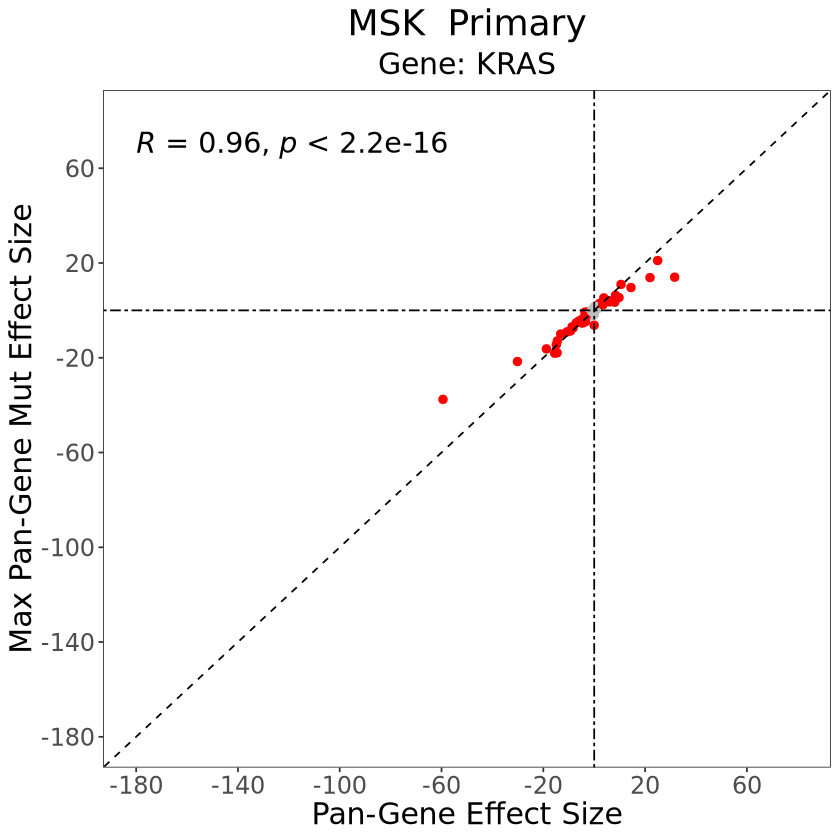

In [42]:
p1

In [43]:
df %>% filter(sign_run!=0)

gene,KRAS_nES,KRAS_G12_nES,KRAS_G13_nES,KRAS_Q61_nES,KRAS_A146_nES,KRAS_A59_nES,type,type_1,type_2,type_3,type_4,type_5,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR,sign_run
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>
AMER1,14.465100,9.6307218,2.27582714,0.000000000,0.349603143,0.000000000,CO,CO,CO,ME,CO,ME,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,3
ANKRD11,2.177942,1.9808270,0.05361544,-0.107676095,0.000000000,0.038948759,CO,CO,CO,ME,ME,CO,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,1
APC,31.618571,14.0195481,7.20047183,0.000000000,4.370372745,0.081808196,CO,CO,CO,ME,CO,CO,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE,4
ARID1A,8.050769,3.4389363,2.46214430,0.000000000,0.162900756,0.000000000,CO,CO,CO,ME,CO,ME,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,3
ARID1B,-2.859555,-0.6358974,-0.52313199,0.000000000,0.000000000,0.000000000,ME,ME,ME,ME,ME,ME,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,1
ATM,9.743593,5.3950205,2.71146836,-0.434743790,-0.450056288,0.000000000,CO,CO,CO,ME,ME,ME,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,3
ATRX,-2.326703,-1.1140372,-0.23954034,-0.111363717,0.000000000,-0.024910071,ME,ME,ME,ME,ME,ME,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,1
BAP1,-5.303328,-5.1334298,0.44989850,-0.004672121,-0.052116626,0.000000000,ME,ME,CO,ME,ME,ME,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,2
CDH1,-7.056414,-5.2999266,0.00000000,0.000000000,0.000000000,0.000000000,ME,ME,ME,ME,ME,ME,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,2


In [44]:
temp <-df %>% filter(sign_run!=0)

In [45]:
head(temp[14:19])

,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR
,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE
2,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE
3,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE
4,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE
5,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE
6,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE


In [46]:
mat<-temp[c(8:13)]

In [47]:
mat[(temp[,c(14:19)]==FALSE)]<-''

In [48]:
rownames(mat)<-temp$gene

In [51]:
colnames(mat)<-c('KRAS','KRAS_G12','KRAS_G13','KRAS_Q61','KRAS_A146','KRAS_A59')

In [52]:
mat

,KRAS,KRAS_G12,KRAS_G13,KRAS_Q61,KRAS_A146,KRAS_A59
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AMER1,CO,CO,CO,,,
ANKRD11,CO,,,,,
APC,CO,CO,CO,,CO,
ARID1A,CO,CO,CO,,,
ARID1B,ME,,,,,
ATM,CO,CO,CO,,,
ATRX,ME,,,,,
BAP1,ME,ME,,,,
CDH1,ME,ME,,,,


In [53]:
df <- reshape2::melt(data=as.matrix(mat))
colnames(df) <- c("x", "y", "value")

In [54]:
df

x,y,value
<fct>,<fct>,<chr>
AMER1,KRAS,CO
ANKRD11,KRAS,CO
APC,KRAS,CO
ARID1A,KRAS,CO
ARID1B,KRAS,ME
ATM,KRAS,CO
ATRX,KRAS,ME
BAP1,KRAS,ME
CDH1,KRAS,ME


In [55]:
options(repr.plot.width = 7, repr.plot.height = 15)
p<-ggplot(df, aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

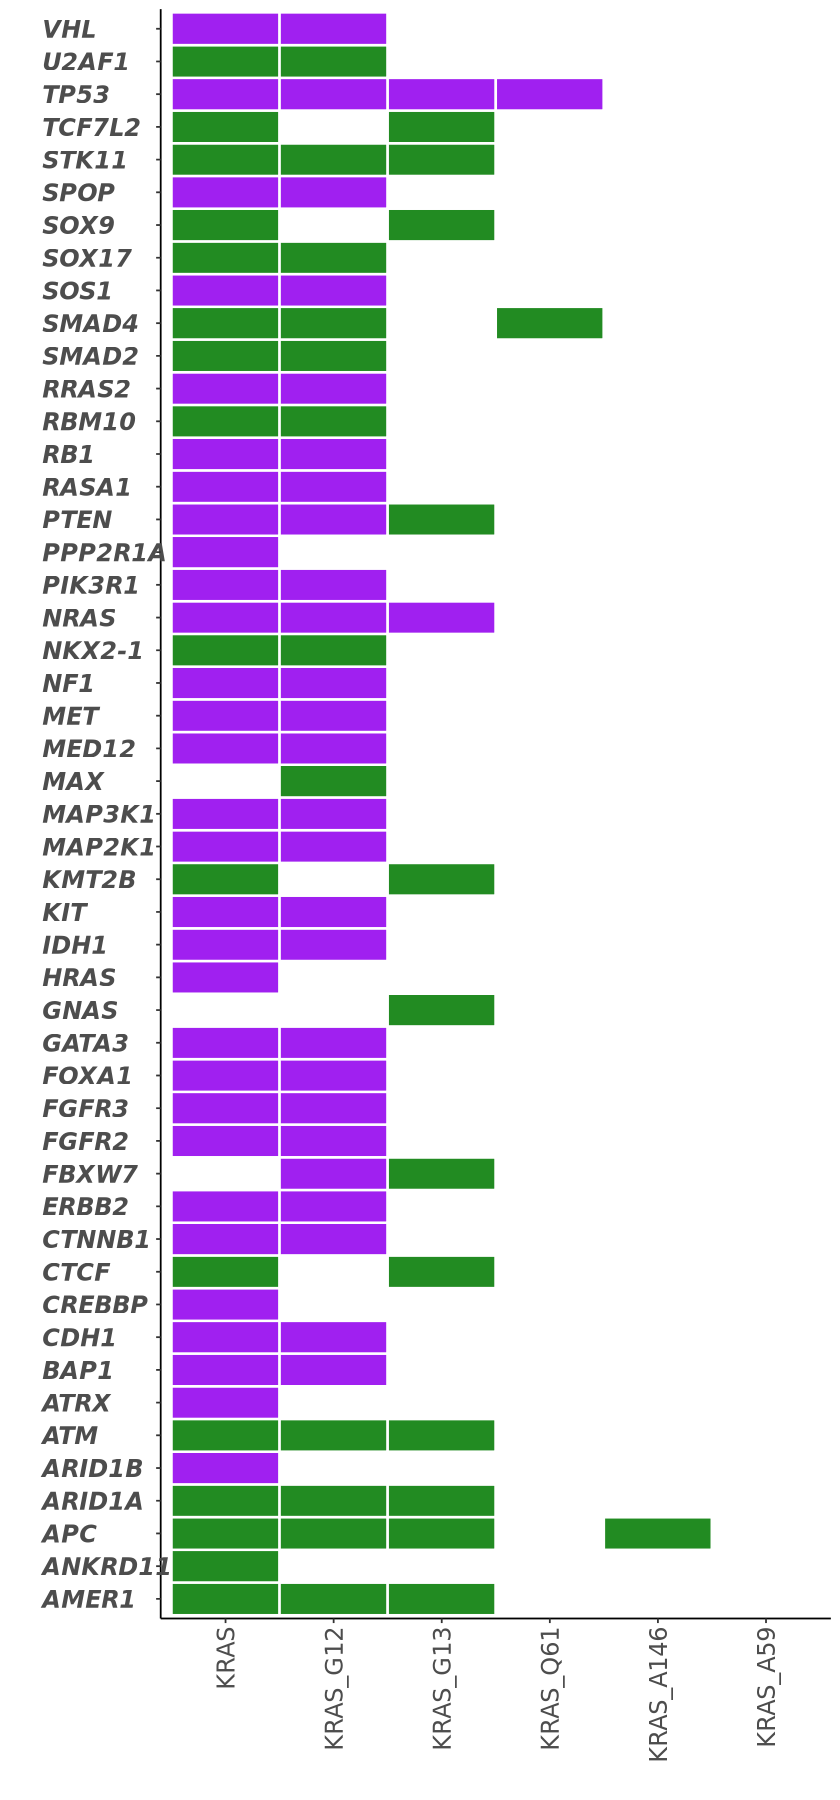

In [56]:
p

In [59]:
kras_df<- df

In [60]:
kras_effect<-temp

## BRAF Specific Analysis

In [61]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='BRAF' | SFE_2=='BRAF'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='BRAF' | SFE_2=='BRAF'))$SFE_2))

In [62]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('BRAF',SFE_1) | grepl('BRAF',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('BRAF',SFE_1) | grepl('BRAF',SFE_2)))$SFE_2))

In [63]:
head(g1)

[1] "BRAF"   "APC"    "AKT1"   "AMER1"  "ARID5B" "BCOR"

In [64]:
head(g2)

[1] "BRAF_1" "APC"    "BRAF_3" "BRAF_2" "AKT1"   "ARID1A"

In [65]:
g2[grepl('BRAF',g2)]

[1] "BRAF_1" "BRAF_3" "BRAF_2"

In [66]:
kras <- (msk_p_missense_result %>% filter(SFE_1=='BRAF' | SFE_2=='BRAF') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [67]:
dim(kras)

[1] 267  22

In [68]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='BRAF' | SFE_2=='BRAF'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='BRAF' | SFE_2=='BRAF'))$SFE_2))

In [69]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('BRAF',SFE_1) | grepl('BRAF',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('BRAF',SFE_1) | grepl('BRAF',SFE_2)))$SFE_2))

In [70]:
g <- intersect(g1,g2)

In [71]:
kras_spec_1 <- (msk_p_hotspot_result %>% filter(SFE_1=='BRAF_1' | SFE_2=='BRAF_1') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_2 <- (msk_p_hotspot_result %>% filter(SFE_1=='BRAF_2' | SFE_2=='BRAF_2') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_3 <- (msk_p_hotspot_result %>% filter(SFE_1=='BRAF_3' | SFE_2=='BRAF_3') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [72]:
kras_spec_1<-kras_spec_1 %>% mutate(GENE= case_when(SFE_1=='BRAF_1' ~ SFE_2,SFE_2=='BRAF_1'  ~ SFE_1))
kras_spec_2<-kras_spec_2 %>% mutate(GENE= case_when(SFE_1=='BRAF_2' ~ SFE_2,SFE_2=='BRAF_2'  ~ SFE_1))
kras_spec_3<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='BRAF_3' ~ SFE_2,SFE_2=='BRAF_3'  ~ SFE_1))

In [73]:
dim(kras_spec_1)
dim(kras_spec_2)
dim(kras_spec_3)

[1] 267  23

[1] 267  23

[1] 267  23

In [74]:
head(kras_spec_1)

,SFE_1,SFE_2,name,support_1,support_2,freq_1,freq_2,overlap,w_overlap,max_overlap,⋯,wES,wFDR,nES,mean_r_nES,nFDR,cum_freq,nFDR2,type,FDR,GENE
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<chr>
APC - BRAF_1,APC,BRAF_1,APC - BRAF_1,1809,395,0.13036898,0.02846642,47,26.8790267,222,⋯,-25.279926,0.003205128,-21.943643,-3.3362832,0.0008175399,2204,0.000000000,ME,TRUE,APC
BRAF_1 - TP53,BRAF_1,TP53,BRAF_1 - TP53,395,6246,0.02846642,0.45012972,119,77.9265088,283,⋯,-25.253764,0.003141786,-21.327055,-3.9267095,0.0009459140,6641,0.001357181,ME,TRUE,TP53
BRAF_1 - NRAS,BRAF_1,NRAS,BRAF_1 - NRAS,395,253,0.02846642,0.01823292,2,0.4651163,189,⋯,-20.466213,0.006178001,-18.161723,-2.3044894,0.0017402181,648,0.000000000,ME,TRUE,NRAS
BRAF_1 - RNF43,BRAF_1,RNF43,BRAF_1 - RNF43,395,429,0.02846642,0.03091669,91,31.9446897,152,⋯,13.114511,0.023027775,12.022724,1.0917870,0.0057247883,824,0.000000000,CO,TRUE,RNF43
BRAF_1 - NF1,BRAF_1,NF1,BRAF_1 - NF1,395,543,0.02846642,0.03913231,10,4.8351828,148,⋯,-7.794315,0.085117698,-6.332783,-1.4615317,0.0309092639,938,0.008036046,ME,TRUE,NF1
BRAF_1 - SETD2,BRAF_1,SETD2,BRAF_1 - SETD2,395,317,0.02846642,0.02284520,32,15.3184528,109,⋯,6.441357,0.122306857,5.557689,0.8836672,0.0433873782,712,0.016025641,CO,TRUE,SETD2


In [75]:
kras<-kras %>% mutate(GENE= case_when(SFE_1!='BRAF' ~ SFE_1,
                        SFE_1=='BRAF'  ~ SFE_2))

kras<-kras %>% arrange(GENE)
kras_spec_1<-kras_spec_1 %>% arrange(GENE)
kras_spec_2<-kras_spec_2 %>% arrange(GENE)
kras_spec_3<-kras_spec_3 %>% arrange(GENE)

In [78]:
kras$Fdr<-'NO'
kras[(kras %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_1$Fdr<-'NO'
kras_spec_1[(kras_spec_1 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_2$Fdr<-'NO'
#kras_spec_2[(kras_spec_2 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_3$Fdr<-'NO'
kras_spec_3[(kras_spec_3 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

In [79]:
df <- data.frame('gene'=kras_spec_1$GENE,
                'BRAF_nES'=kras$nES,
                'BRAF_1_nES'=kras_spec_1$nES,
                'BRAF_2_nES'=kras_spec_2$nES,
                'BRAF_3_nES'=kras_spec_3$nES,
                'type'=kras$type,
                'type_1'=kras_spec_1$type,
                'type_2'=kras_spec_2$type,
                'type_3'=kras_spec_3$type,
                'type_FDR'=kras$FDR,
                'type_1_FDR'=kras_spec_1$FDR,
                'type_2_FDR'=kras_spec_2$FDR,
                'type_3_FDR'=kras_spec_3$FDR
                )

In [80]:
head(df,2)

,gene,BRAF_nES,BRAF_1_nES,BRAF_2_nES,BRAF_3_nES,type,type_1,type_2,type_3,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
1,ABL1,0,0,0.02798916,0,ME,ME,CO,ME,FALSE,FALSE,FALSE,FALSE
2,ACVR1,0,0,0.00000000,0,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE


In [81]:
mat<-(df[,c(3:5)])
row.names(mat)<-df$gene

In [82]:
scatter_df <- data.frame('gene'=df$gene)
scatter_df$pan_gene_nES<-df$BRAF_nES

In [83]:
scatter_df$best_mut_nES<-mat[cbind(1:nrow(mat), max.col(abs(mat)))]
scatter_df$label<-(mat %>%
  mutate(Class = names(.)[max.col(.)]))$Class

In [84]:
df$sign_run <- rowSums(df[,c(10:13)])

In [85]:
scatter_df$sign_run<-as.factor(df$sign_run)

In [86]:
head(scatter_df)

,gene,pan_gene_nES,best_mut_nES,label,sign_run
,<chr>,<dbl>,<dbl>,<chr>,<fct>
1,ABL1,0.000000,0.027989163,BRAF_2_nES,0
2,ACVR1,0.000000,0.000000000,BRAF_3_nES,0
3,AKT1,3.114033,3.287147945,BRAF_1_nES,2
4,AKT2,0.000000,0.000000000,BRAF_2_nES,0
5,AKT3,0.000000,0.276342441,BRAF_1_nES,0
6,ALK,0.000000,-0.005668571,BRAF_1_nES,0


In [87]:
options(repr.plot.width = 7, repr.plot.height = 7)
options(ggrepel.max.overlaps = 100)
#p1<-
p2<-ggscatter(scatter_df,
          x='pan_gene_nES',
          y='best_mut_nES',
          color='sign_run',
          fill='sign_run',
          palette= c("grey","red", "red", "red","red"),
          repel = TRUE,
          #label='gene',
          #label.select= c('NF1','SAMD4'),
          font.label = c(10, "bold"))+
          theme_bw()+stat_cor(size=6)+
#         ggrepel::geom_text_repel(
#                 data = (scatter_df %>% filter(gene %in% ('NF1','SMAD4','KEA'))),
#                 aes(label = gene),
#                 size = 4,
#                 box.padding = unit(0.7, "lines"),
#                 point.padding = unit(0.7, "lines"))+
geom_hline(yintercept = 0,linetype=6)+
geom_vline(xintercept = 0,linetype=6)+
geom_abline(slope = 1,intercept = 0,linetype=2)+
ggtitle('MSK  Primary')+labs(subtitle = 'Gene: BRAF')+
theme_bw()+
xlab('Pan-Gene Effect Size')+
ylab('Max Pan-Gene Mut Effect Size')+
scale_x_continuous(breaks = seq(from = -80, to = 30, by = 10),limits = c(-80, 30))+
scale_y_continuous(breaks = seq(from = -80, to = 30 , by = 10),limits = c(-80, 30))+
theme(plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      text = element_text(size = 18),
      legend.position = 'none',
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.title = element_blank())

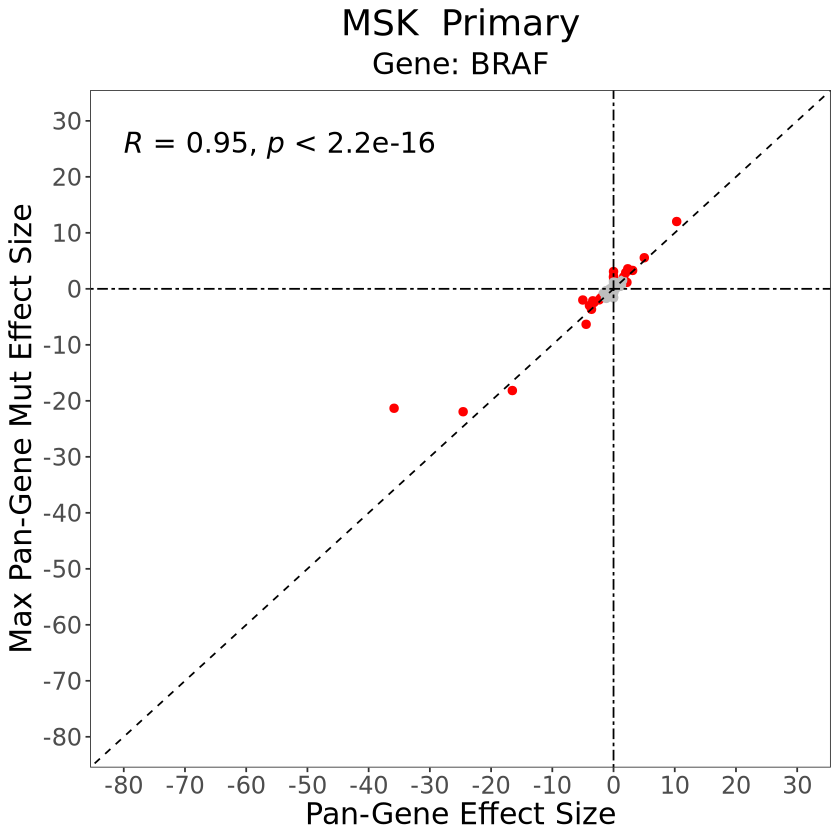

In [88]:
p2

In [89]:
temp <-df %>% filter(sign_run!=0)

In [90]:
mat<-temp[c(6:9)]
mat[(temp[,c(10:13)]==FALSE)]<-''
rownames(mat)<-temp$gene
colnames(mat)<-c('BRAF','BRAF_1','BRAF_2','BRAF_3')

In [91]:
df <- reshape2::melt(data=as.matrix(mat))
colnames(df) <- c("x", "y", "value")

In [92]:
options(repr.plot.width = 7, repr.plot.height = 9)
p<-ggplot(df, aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

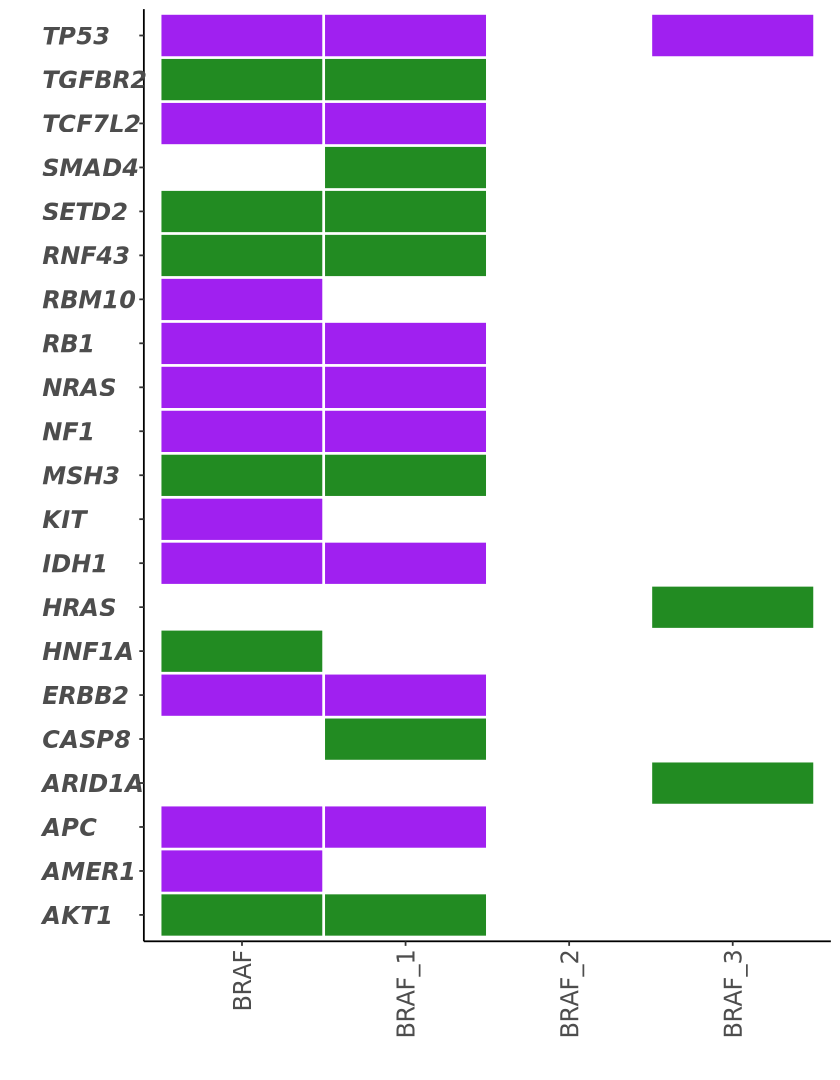

In [93]:
p

In [94]:
braf_df<- df

In [95]:
braf_effect<-temp

## EGFR Specific Analysis

In [96]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='EGFR' | SFE_2=='EGFR'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='EGFR' | SFE_2=='EGFR'))$SFE_2))

In [97]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('EGFR',SFE_1) | grepl('EGFR',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('EGFR',SFE_1) | grepl('EGFR',SFE_2)))$SFE_2))

In [98]:
head(g1)

[1] "EGFR"   "ARID1A" "BRAF"   "ATM"    "APC"    "ATRX"

In [99]:
head(g2)

[1] "EGFR_3" "EGFR_2" "EGFR_1" "ARID1A" "ATRX"   "ATM"

In [100]:
g2[grepl('EGFR',g2)]

[1] "EGFR_3"    "EGFR_2"    "EGFR_1"    "EGFR_G598" "EGFR_R108"

In [101]:
kras <- (msk_p_missense_result %>% filter(SFE_1=='EGFR' | SFE_2=='EGFR') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [102]:
dim(kras)

[1] 267  22

In [103]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='EGFR' | SFE_2=='EGFR'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='EGFR' | SFE_2=='EGFR'))$SFE_2))

In [104]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('EGFR',SFE_1) | grepl('EGFR',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('EGFR',SFE_1) | grepl('EGFR',SFE_2)))$SFE_2))

In [105]:
g <- intersect(g1,g2)

In [106]:
kras_spec_1 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_1' | SFE_2=='EGFR_1') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_2 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_2' | SFE_2=='EGFR_2') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_3 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_3' | SFE_2=='EGFR_3') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_4 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_R108' | SFE_2=='EGFR_R108') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_5 <- (msk_p_hotspot_result %>% filter(SFE_1=='EGFR_G598' | SFE_2=='EGFR_G598') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [107]:
kras_spec_1<-kras_spec_1 %>% mutate(GENE= case_when(SFE_1=='EGFR_1' ~ SFE_2,SFE_2=='EGFR_1'  ~ SFE_1))
kras_spec_2<-kras_spec_2 %>% mutate(GENE= case_when(SFE_1=='EGFR_2' ~ SFE_2,SFE_2=='EGFR_2'  ~ SFE_1))
kras_spec_3<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='EGFR_3' ~ SFE_2,SFE_2=='EGFR_3'  ~ SFE_1))
kras_spec_4<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='EGFR_R108' ~ SFE_2,SFE_2=='EGFR_R108'  ~ SFE_1))
kras_spec_5<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='EGFR_G598' ~ SFE_2,SFE_2=='EGFR_G598'  ~ SFE_1))

In [108]:
dim(kras_spec_1)
dim(kras_spec_2)
dim(kras_spec_3)
dim(kras_spec_4)
dim(kras_spec_5)

[1] 267  23

[1] 267  23

[1] 267  23

[1] 267  23

[1] 267  23

In [109]:
kras<-kras %>% mutate(GENE= case_when(SFE_1!='EGFR' ~ SFE_1,
                        SFE_1=='EGFR'  ~ SFE_2))

kras<-kras %>% arrange(GENE)
kras_spec_1<-kras_spec_1 %>% arrange(GENE)
kras_spec_2<-kras_spec_2 %>% arrange(GENE)
kras_spec_3<-kras_spec_3 %>% arrange(GENE)
kras_spec_4<-kras_spec_4 %>% arrange(GENE)
kras_spec_5<-kras_spec_5 %>% arrange(GENE)

In [110]:
kras$Fdr<-'NO'
kras[(kras %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_1$Fdr<-'NO'
kras_spec_1[(kras_spec_1 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_2$Fdr<-'NO'
kras_spec_2[(kras_spec_2 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_3$Fdr<-'NO'
kras_spec_3[(kras_spec_3 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_4$Fdr<-'NO'
kras_spec_4[(kras_spec_4 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_5$Fdr<-'NO'
kras_spec_5[(kras_spec_5 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

In [111]:
df <- data.frame('gene'=kras_spec_1$GENE,
                'EGFR_nES'=kras$nES,
                'EGFR_1'=kras_spec_1$nES,
                'EGFR_2'=kras_spec_2$nES,
                'EGFR_3'=kras_spec_3$nES,
                'EGFR_R108'=kras_spec_3$nES,
                'EGFR_G598'=kras_spec_3$nES,
                'type'=kras$type,
                'type_1'=kras_spec_1$type,
                'type_2'=kras_spec_2$type,
                'type_3'=kras_spec_3$type,
                'type_4'=kras_spec_4$type,
                'type_5'=kras_spec_5$type,                 
                'type_FDR'=kras$FDR,
                'type_1_FDR'=kras_spec_1$FDR,
                'type_2_FDR'=kras_spec_2$FDR,
                'type_3_FDR'=kras_spec_3$FDR,
                'type_4_FDR'=kras_spec_4$FDR,
                'type_5_FDR'=kras_spec_5$FDR                 
                )

In [112]:
mat<-(df[,c(3:7)])
rownames(mat)<-df$gene

In [113]:
scatter_df <- data.frame('gene'=df$gene)
scatter_df$pan_gene_nES<-df$EGFR_nES

In [114]:
scatter_df$best_mut_nES<-mat[cbind(1:nrow(mat), max.col(abs(mat)))]
scatter_df$label<-(mat %>%
  mutate(Class = names(.)[max.col(.)]))$Class

In [115]:
df$sign_run <- rowSums(df[,c(15:19)])

In [116]:
scatter_df$sign_run<-as.factor(df$sign_run)

In [117]:
head(scatter_df)

,gene,pan_gene_nES,best_mut_nES,label,sign_run
,<chr>,<dbl>,<dbl>,<chr>,<fct>
1,ABL1,0.0000000,-0.04084739,EGFR_1,2
2,ACVR1,0.0000000,0.00000000,EGFR_3,2
3,AKT1,-0.8220299,-0.15217382,EGFR_2,2
4,AKT2,0.0000000,0.00000000,EGFR_2,2
5,AKT3,-0.2178049,0.00000000,EGFR_R108,2
6,ALK,-0.4677537,0.09747310,EGFR_2,2


In [118]:
options(repr.plot.width = 7, repr.plot.height = 7)
options(ggrepel.max.overlaps = 100)
#p1<-
p3<-ggscatter(scatter_df,
          x='pan_gene_nES',
          y='best_mut_nES',
          color='sign_run',
          fill='sign_run',
          palette= c("grey","red", "red", "red","red"),
          repel = TRUE,
          #label='gene',
          #label.select= c('NF1','SAMD4'),
          font.label = c(10, "bold"))+
          theme_bw()+stat_cor(size=6)+
#         ggrepel::geom_text_repel(
#                 data = (scatter_df %>% filter(gene %in% ('NF1','SMAD4','KEA'))),
#                 aes(label = gene),
#                 size = 4,
#                 box.padding = unit(0.7, "lines"),
#                 point.padding = unit(0.7, "lines"))+
geom_hline(yintercept = 0,linetype=6)+
geom_vline(xintercept = 0,linetype=6)+
geom_abline(slope = 1,intercept = 0,linetype=2)+
ggtitle('MSK  Primary')+labs(subtitle = 'Gene: EGFR')+
theme_bw()+
xlab('Pan-Gene Effect Size')+
ylab('Max Pan-Gene Mut Effect Size')+
scale_x_continuous(breaks = seq(from = -70, to = 20, by = 10),limits = c(-70, 20))+
scale_y_continuous(breaks = seq(from = -70, to =20 , by = 10),limits = c(-70, 20))+
theme(plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      text = element_text(size = 18),
      legend.position = 'none',
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.title = element_blank())

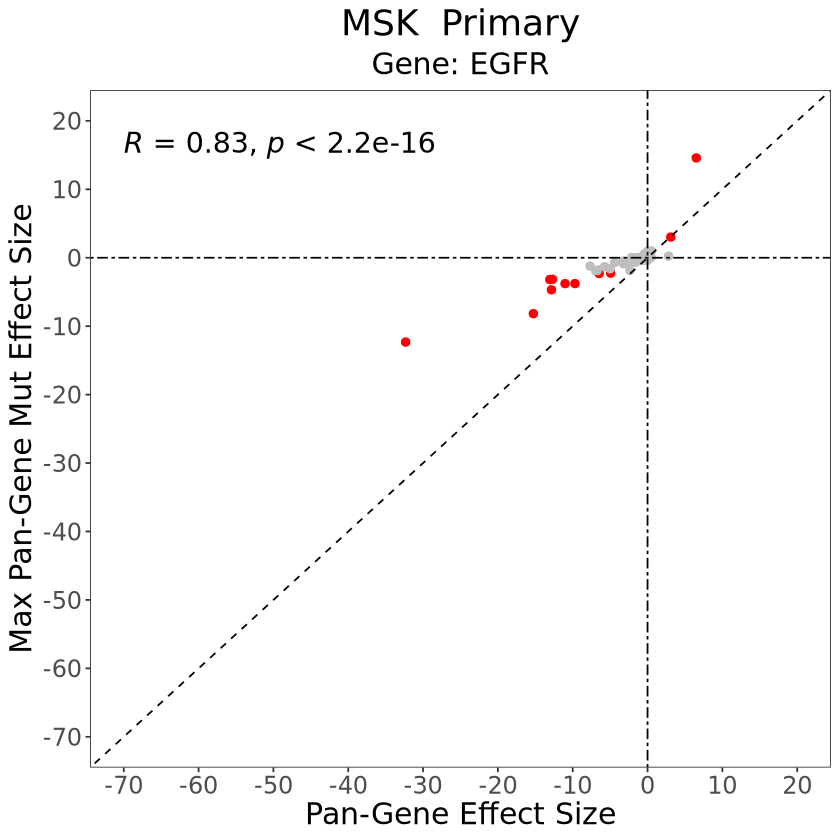

In [119]:
p3

In [120]:
temp <-df %>% filter(sign_run!=0)

In [121]:
temp

gene,EGFR_nES,EGFR_1,EGFR_2,EGFR_3,EGFR_R108,EGFR_G598,type,type_1,type_2,type_3,type_4,type_5,type_FDR,type_1_FDR,type_2_FDR,type_3_FDR,type_4_FDR,type_5_FDR,sign_run
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>
ABL1,0.0000000,0.00000000,-0.01126962,-0.04084739,-0.04084739,-0.04084739,ME,ME,ME,ME,CO,CO,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
ACVR1,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
AKT1,-0.8220299,-0.08425582,0.00000000,-0.15217382,-0.15217382,-0.15217382,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
AKT2,0.0000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
AKT3,-0.2178049,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
ALK,-0.4677537,0.00000000,0.09747310,0.00000000,0.00000000,0.00000000,ME,ME,CO,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
AMER1,-0.9679665,0.00000000,-0.03514419,-0.31023957,-0.31023957,-0.31023957,ME,ME,ME,ME,ME,ME,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,2
ARID1A,-12.7121430,-0.03208032,0.00000000,-3.14803788,-3.14803788,-3.14803788,ME,ME,ME,ME,ME,ME,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,1
ATRX,-6.4626959,-2.30022034,-0.60616570,0.00000000,0.00000000,0.00000000,ME,ME,ME,ME,ME,ME,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,1


In [122]:
mat<-temp[c(8:13)]
mat[(temp[,c(14:19)]==FALSE)]<-''
rownames(mat)<-temp$gene
colnames(mat)<-c('EGFR','EGFR_1','EGFR_2','EGFR_3','EGFR_R108','EGFR_G598')

In [123]:
df <- reshape2::melt(data=as.matrix(mat))
colnames(df) <- c("x", "y", "value")

In [124]:
options(repr.plot.width = 7, repr.plot.height = 9)
p<-ggplot(df, aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

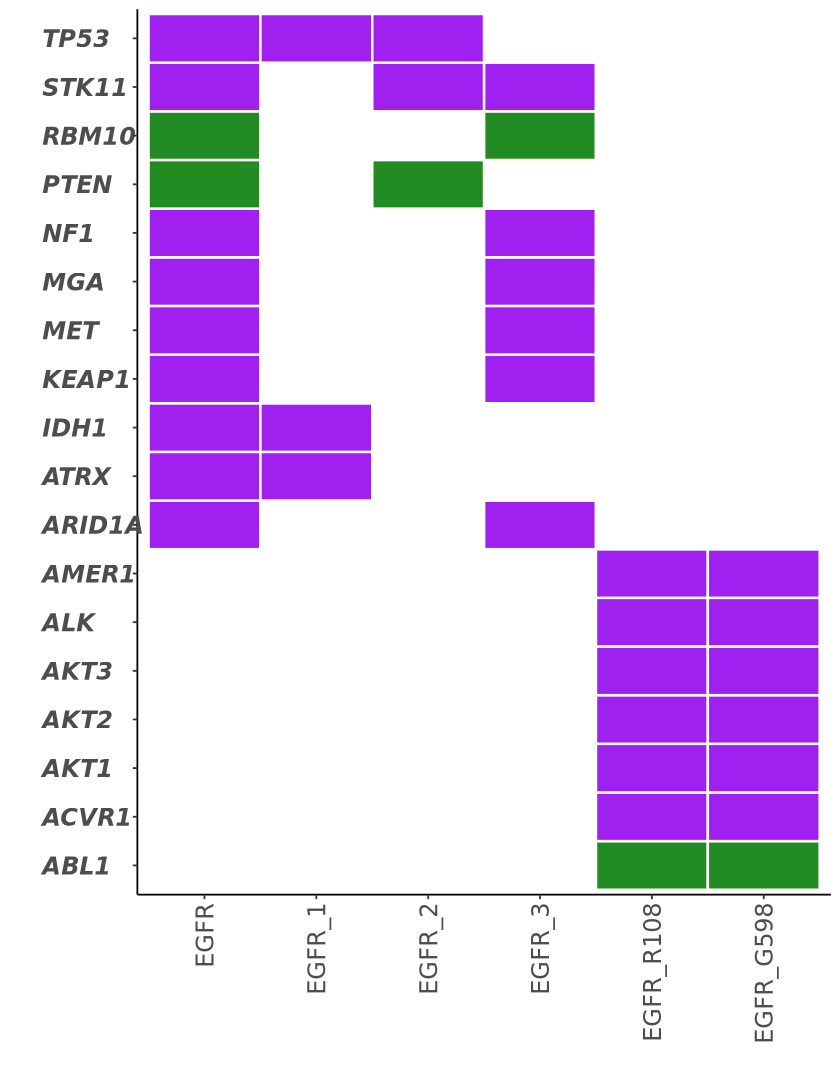

In [125]:
p

In [126]:
egfr_df<- df

In [127]:
egfr_effect<-temp

## PIK3CA Specific Analysis

In [133]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA'))$SFE_2))

In [134]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('PIK3CA',SFE_1) | grepl('PIK3CA',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('PIK3CA',SFE_1) | grepl('PIK3CA',SFE_2)))$SFE_2))

In [135]:
head(g1)

[1] "PIK3CA" "ARID1A" "MAP3K1" "KRAS"   "AKT1"   "CDH1"

In [136]:
head(g2)

[1] "PIK3CA_3" "PIK3CA_5" "PIK3CA_1" "ARID1A"   "PIK3CA_2" "MAP3K1"

In [137]:
g2[grepl('PIK3CA',g2)]

[1] "PIK3CA_3" "PIK3CA_5" "PIK3CA_1" "PIK3CA_2" "PIK3CA_4"

In [138]:
kras <- (msk_p_missense_result %>% filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [139]:
dim(kras)

[1] 267  22

In [140]:
g1<-unique(c((msk_p_missense_result %>%filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA'))$SFE_1,(msk_p_missense_result %>%filter(SFE_1=='PIK3CA' | SFE_2=='PIK3CA'))$SFE_2))

In [141]:
g2<-unique(c((msk_p_hotspot_result %>%filter(grepl('PIK3CA',SFE_1) | grepl('PIK3CA',SFE_2)))$SFE_1,(msk_p_hotspot_result %>%filter(grepl('PIK3CA',SFE_1) | grepl('PIK3CA',SFE_2)))$SFE_2))

In [142]:
g <- intersect(g1,g2)

In [143]:
kras_spec_1 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_1' | SFE_2=='PIK3CA_1') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_2 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_2' | SFE_2=='PIK3CA_2') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_3 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_3' | SFE_2=='PIK3CA_3') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_4 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_4' | SFE_2=='PIK3CA_4') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )
kras_spec_5 <- (msk_p_hotspot_result %>% filter(SFE_1=='PIK3CA_5' | SFE_2=='PIK3CA_5') %>% filter(SFE_1 %in% g | SFE_2 %in% g) )

In [144]:
kras_spec_1<-kras_spec_1 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_1' ~ SFE_2,SFE_2=='PIK3CA_1'  ~ SFE_1))
kras_spec_2<-kras_spec_2 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_2' ~ SFE_2,SFE_2=='PIK3CA_2'  ~ SFE_1))
kras_spec_3<-kras_spec_3 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_3' ~ SFE_2,SFE_2=='PIK3CA_3'  ~ SFE_1))
kras_spec_4<-kras_spec_4 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_4' ~ SFE_2,SFE_2=='PIK3CA_4'  ~ SFE_1))
kras_spec_5<-kras_spec_5 %>% mutate(GENE= case_when(SFE_1=='PIK3CA_5' ~ SFE_2,SFE_2=='PIK3CA_5'  ~ SFE_1))

In [145]:
dim(kras_spec_1)
dim(kras_spec_2)
dim(kras_spec_3)
dim(kras_spec_4)
dim(kras_spec_5)

[1] 267  23

[1] 267  23

[1] 267  23

[1] 267  23

[1] 267  23

In [146]:
kras<-kras %>% mutate(GENE= case_when(SFE_1!='PIK3CA' ~ SFE_1,
                        SFE_1=='PIK3CA'  ~ SFE_2))

kras<-kras %>% arrange(GENE)
kras_spec_1<-kras_spec_1 %>% arrange(GENE)
kras_spec_2<-kras_spec_2 %>% arrange(GENE)
kras_spec_3<-kras_spec_3 %>% arrange(GENE)
kras_spec_4<-kras_spec_4 %>% arrange(GENE)
kras_spec_5<-kras_spec_5 %>% arrange(GENE)

In [147]:
kras$Fdr<-'NO'
kras[(kras %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_1$Fdr<-'NO'
kras_spec_1[(kras_spec_1 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_2$Fdr<-'NO'
kras_spec_2[(kras_spec_2 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_3$Fdr<-'NO'
kras_spec_3[(kras_spec_3 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_4$Fdr<-'NO'
#kras_spec_4[(kras_spec_4 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

kras_spec_5$Fdr<-'NO'
kras_spec_5[(kras_spec_5 %>% filter(nFDR2<=0.25))$name,]$Fdr<-'YES'

In [148]:
df <- data.frame('gene'=kras_spec_1$GENE,
                'PIK3CA_nES'=kras$nES,
                'PIK3CA_1'=kras_spec_1$nES,
                'PIK3CA_2'=kras_spec_2$nES,
                'PIK3CA_3'=kras_spec_3$nES,
                'PIK3CA_4'=kras_spec_4$nES,
                'PIK3CA_5'=kras_spec_5$nES,
                'type'=kras$type,
                'type_1'=kras_spec_1$type,
                'type_2'=kras_spec_2$type,
                'type_3'=kras_spec_3$type,
                'type_4'=kras_spec_4$type,
                'type_5'=kras_spec_5$type,
                'type_FDR'=kras$FDR,
                'type_1_FDR'=kras_spec_1$FDR,
                'type_2_FDR'=kras_spec_2$FDR,
                'type_3_FDR'=kras_spec_3$FDR,
                'type_4_FDR'=kras_spec_4$FDR,
                'type_5_FDR'=kras_spec_5$FDR
                )

In [149]:
mat<-(df[,c(3:7)])
rownames(mat)<-df$gene

In [150]:
scatter_df <- data.frame('gene'=df$gene)
scatter_df$pan_gene_nES<-df$PIK3CA_nES

In [151]:
scatter_df$best_mut_nES<-mat[cbind(1:nrow(mat), max.col(abs(mat)))]
scatter_df$label<-(mat %>%
  mutate(Class = names(.)[max.col(.)]))$Class

In [152]:
df$sign_run <- rowSums(df[,c(14:19)])

In [153]:
scatter_df$sign_run<-as.factor(df$sign_run)

In [154]:
head(scatter_df)

,gene,pan_gene_nES,best_mut_nES,label,sign_run
,<chr>,<dbl>,<dbl>,<chr>,<fct>
1,ABL1,0.7238044,0.89143429,PIK3CA_3,0
2,ACVR1,0.0000000,-0.86828014,PIK3CA_2,0
3,AKT1,-20.7076051,-10.60472209,PIK3CA_4,3
4,AKT2,0.0000000,0.09523275,PIK3CA_4,0
5,AKT3,0.0000000,0.16406451,PIK3CA_5,0
6,ALK,-1.0302350,-0.12478189,PIK3CA_2,0


In [155]:
min(scatter_df$pan_gene_nES)

[1] -205.5473

In [156]:
options(repr.plot.width = 7, repr.plot.height = 7)
options(ggrepel.max.overlaps = 100)
#p1<-
p4<-ggscatter(scatter_df,
          x='pan_gene_nES',
          y='best_mut_nES',
          color='sign_run',
          fill='sign_run',
          palette= c("grey","red", "red", "red","red","red"),
          repel = TRUE,
          #label='gene',
          #label.select= c('NF1','SAMD4'),
          font.label = c(10, "bold"))+
          theme_bw()+stat_cor(size=6)+
#         ggrepel::geom_text_repel(
#                 data = (scatter_df %>% filter(gene %in% ('NF1','SMAD4','KEA'))),
#                 aes(label = gene),
#                 size = 4,
#                 box.padding = unit(0.7, "lines"),
#                 point.padding = unit(0.7, "lines"))+
geom_hline(yintercept = 0,linetype=6)+
geom_vline(xintercept = 0,linetype=6)+
geom_abline(slope = 1,intercept = 0,linetype=2)+
ggtitle('MSK  Primary')+labs(subtitle = 'Gene: PIK3CA')+
theme_bw()+
xlab('Pan-Gene Effect Size')+
ylab('Max Pan-Gene Mut Effect Size')+
scale_x_continuous(breaks = seq(from = -300, to = 100, by = 50),limits = c(-300, 100))+
scale_y_continuous(breaks = seq(from = -300, to = 100 , by = 50),limits = c(-300, 100))+
theme(plot.title = element_text(hjust = 0.5),
      plot.subtitle = element_text(hjust = 0.5),
      text = element_text(size = 18),
      legend.position = 'none',
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.title = element_blank())

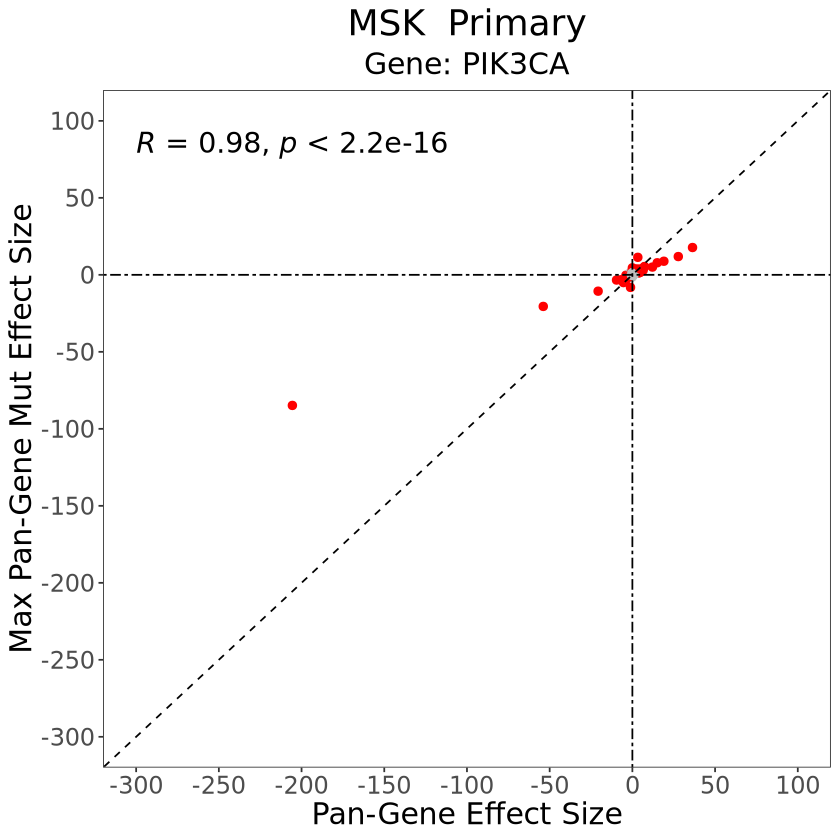

In [157]:
p4

In [158]:
temp <-df %>% filter(sign_run!=0)

In [159]:
mat<-temp[c(8:13)]
mat[(temp[,c(14:19)]==FALSE)]<-''
rownames(mat)<-temp$gene
colnames(mat)<-c('PIK3CA','PIK3CA_1','PIK3CA_2','PIK3CA_3','PIK3CA_4','PIK3CA_5')

In [160]:
df <- reshape2::melt(data=as.matrix(mat))
colnames(df) <- c("x", "y", "value")

In [161]:
options(repr.plot.width = 7, repr.plot.height = 15)
p<-ggplot(df, aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

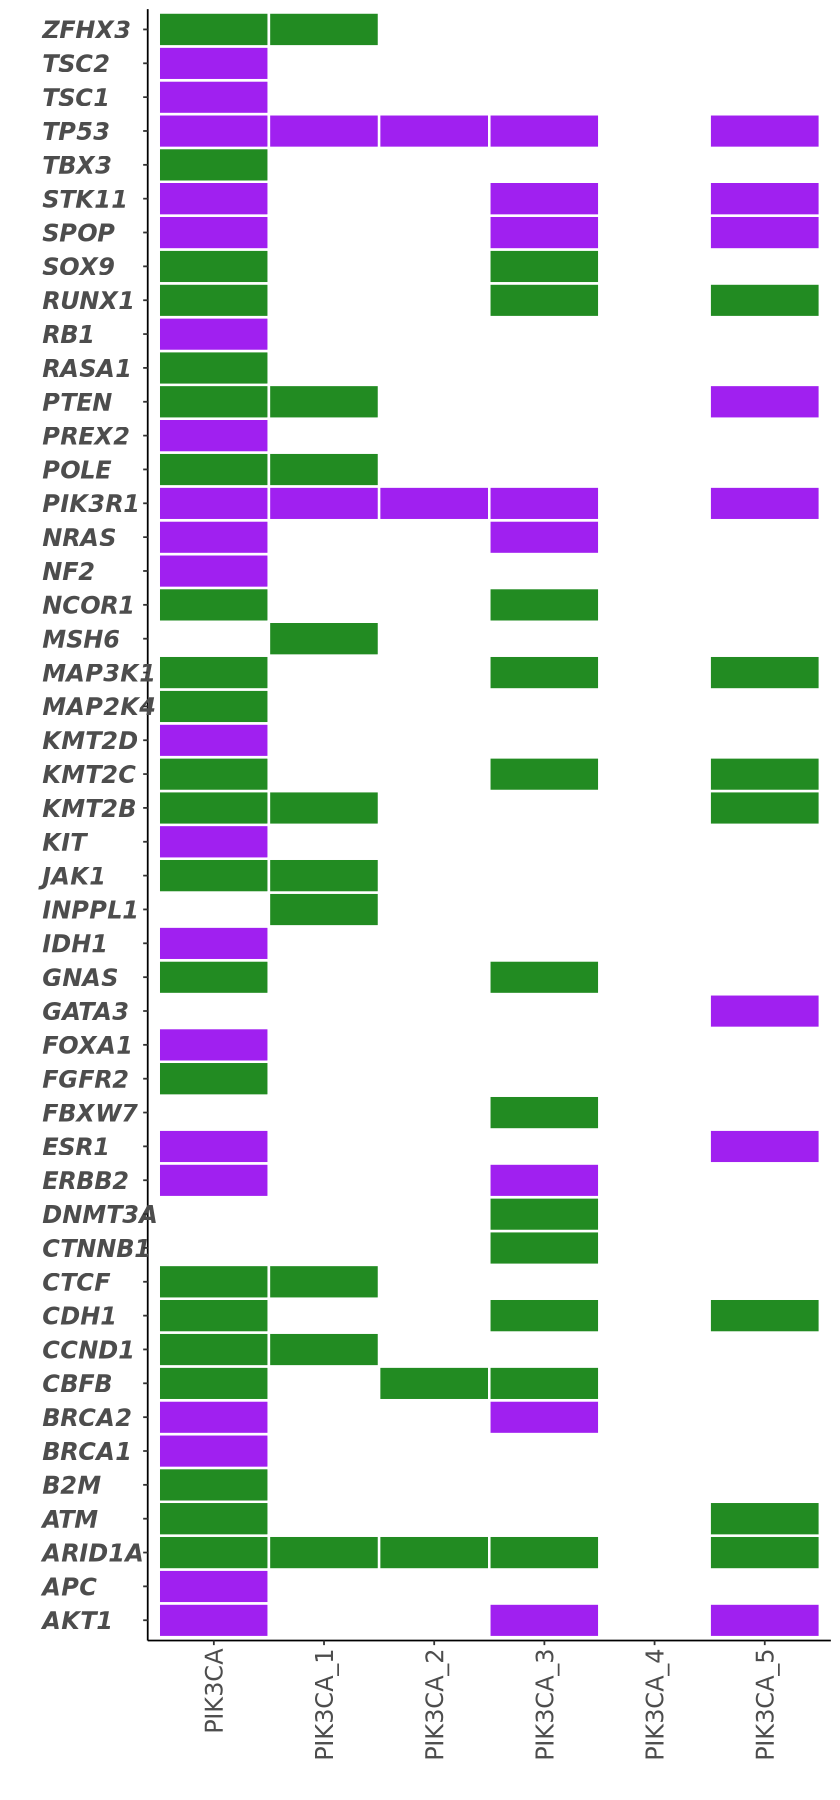

In [162]:
p

In [163]:
pikca_df<-df

In [164]:
pikca_effect<-temp

## Combining Scatter Plot

In [165]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot<-ggarrange(p1,p2,p3,p4,nrow=2,ncol=2)

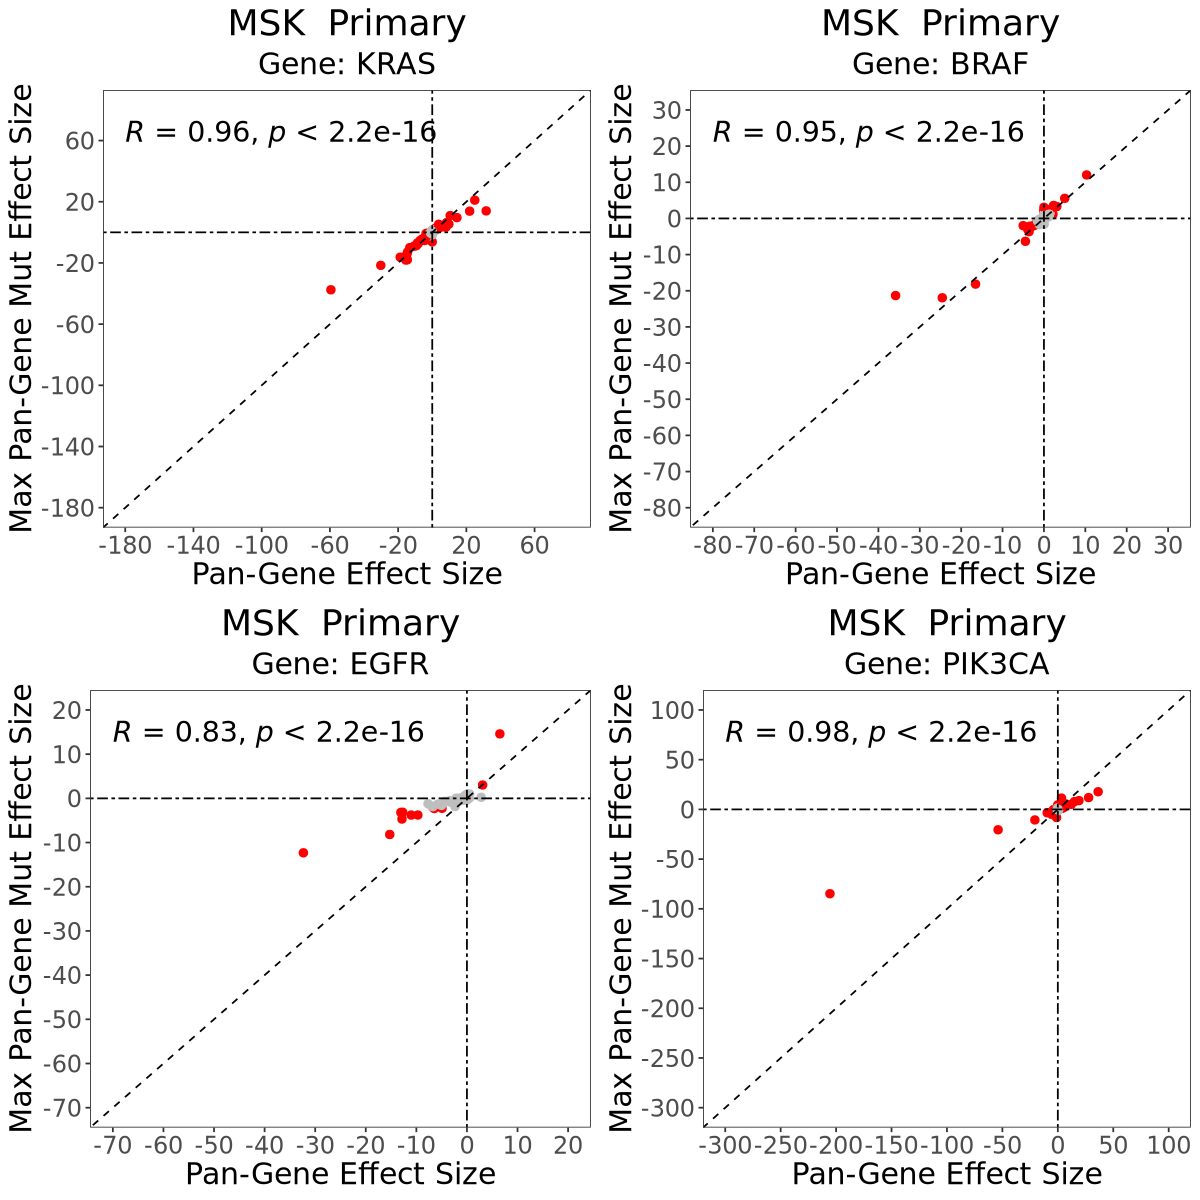

In [166]:
plot

In [167]:
ggsave("../figures/468_panel_msk_hotspot_effect_size_plot.pdf", plot, width = 10, height = 10)

In [168]:
heatmap_df<-bind_rows(kras_df,braf_df,egfr_df,pikca_df)

In [169]:
`%notin%` <- Negate(`%in%`)

In [170]:
head(heatmap_df)

,x,y,value
,<fct>,<fct>,<chr>
1,AMER1,KRAS,CO
2,ANKRD11,KRAS,CO
3,APC,KRAS,CO
4,ARID1A,KRAS,CO
5,ARID1B,KRAS,ME
6,ATM,KRAS,CO


In [173]:
options(repr.plot.width = 10, repr.plot.height = 25)
p<-ggplot(heatmap_df %>%filter(y %notin% c('KRAS_A59','BRAF_2')), aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.7,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'bold.italic',hjus=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))+geom_hline(yintercept = 0)+geom_vline(xintercept = 0)

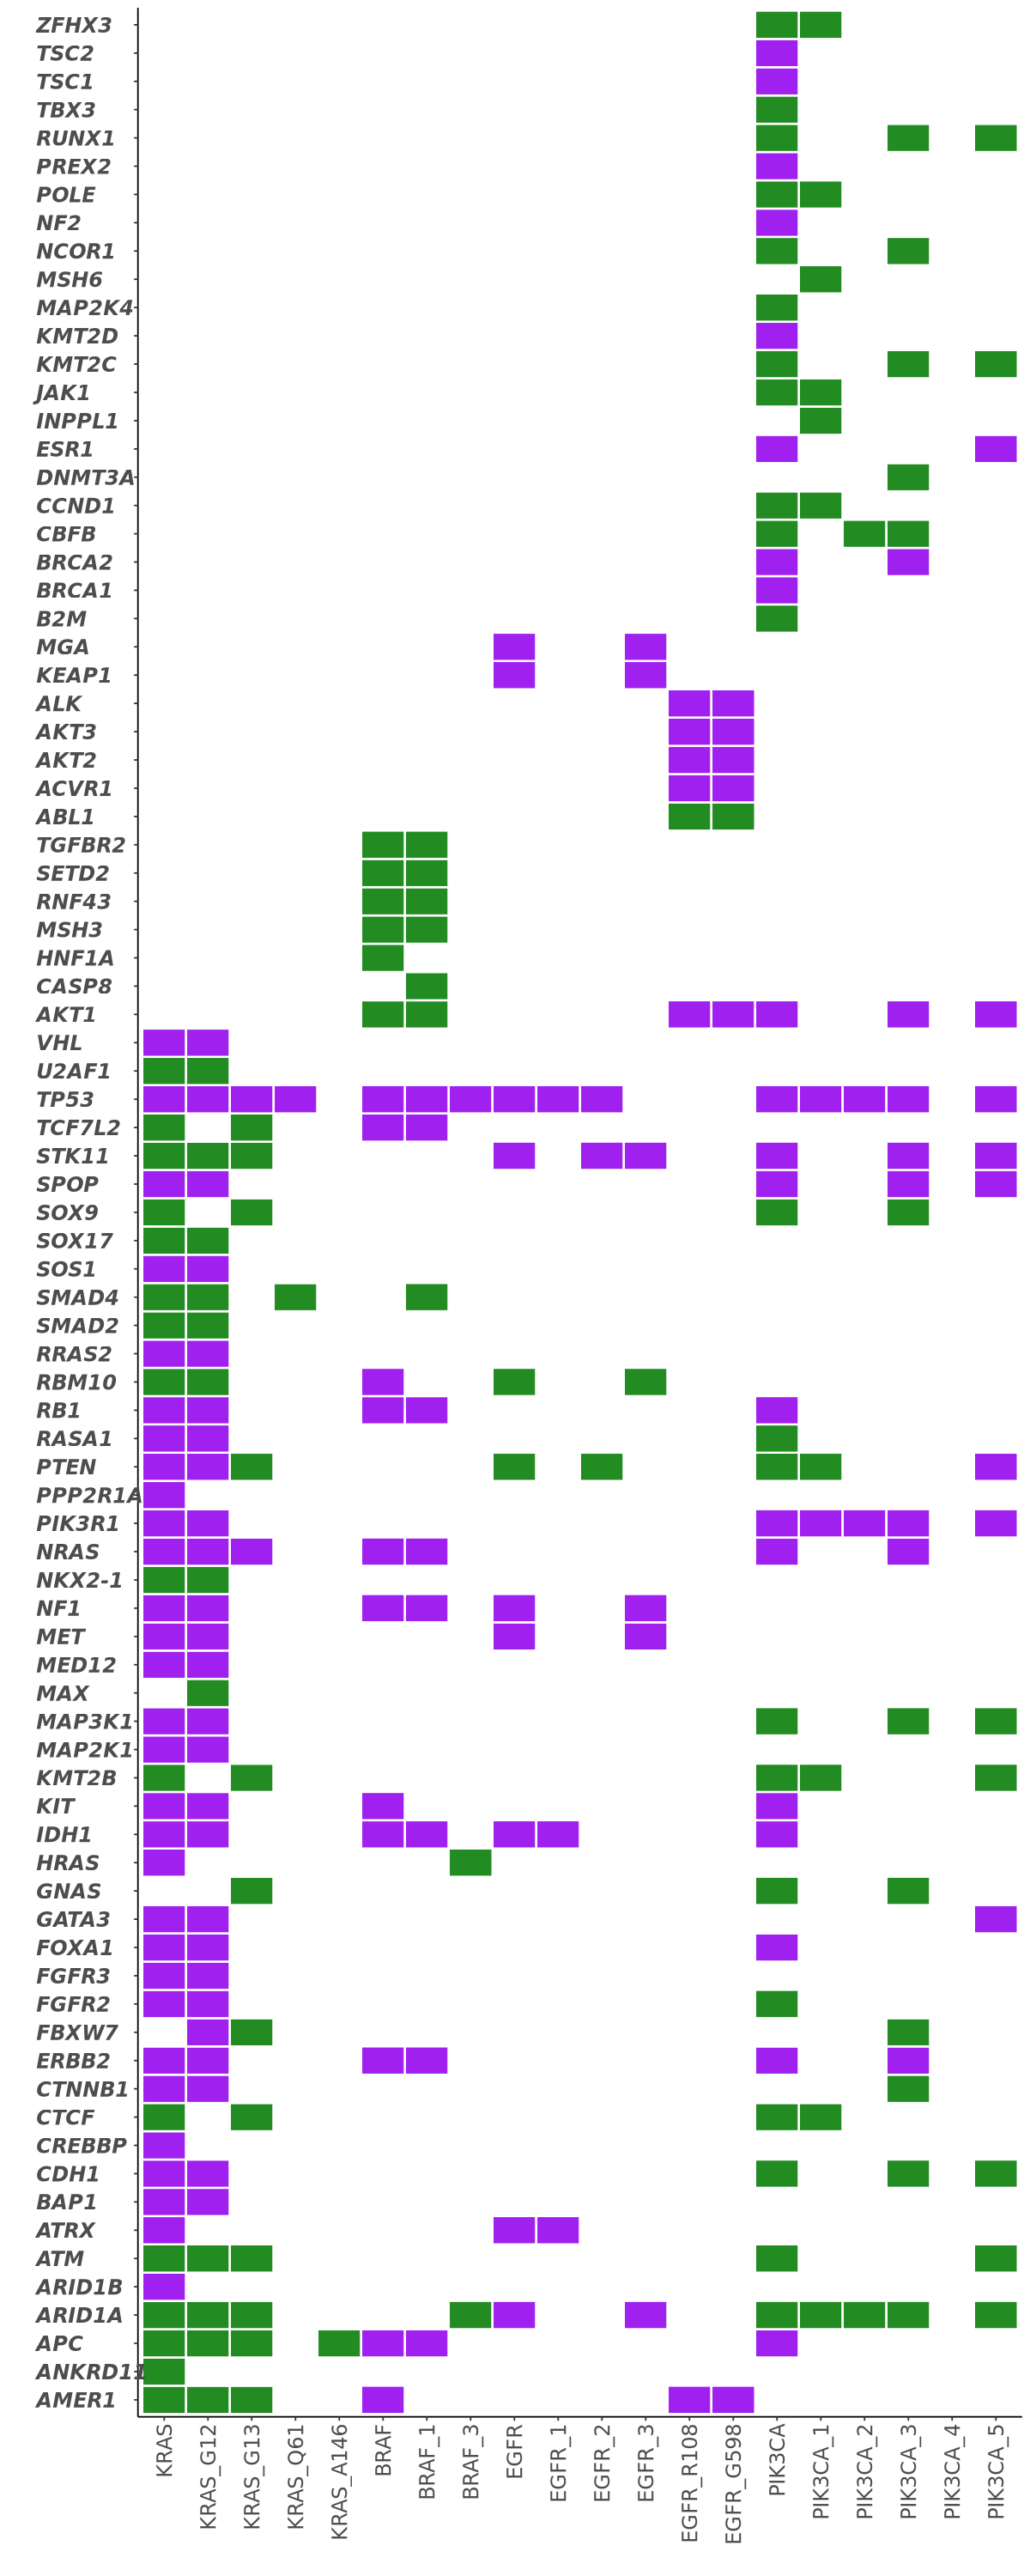

In [174]:
p

In [175]:
plot_genes<-c('FBXW7','KDM6A','KEAP1','NF1','SF3B1','SMAD4','ARID1A','ERBB3','HRAS','STK11','MLH1','AKT1',
'ARID5B','AR','ARAF','SMARCA4','APC','CTNNB1','GATA3','NOTCH1','PBRM1','PTEN','ASXL1','CIC','MTOR','ABL1')

In [176]:
options(repr.plot.width = 9, repr.plot.height = 9)
p<-ggplot(heatmap_df %>%filter(y %notin% c('KRAS_A59','BRAF_2')) %>% filter(x %in% plot_genes) , aes(x = y, y = x, fill = value)) +
  geom_tile(color = "white",
            lwd = 0.9,
            linetype = 1)+theme_bw()+xlab('')+ylab('')+
scale_fill_manual(values = c('white','forestgreen','purple'))+theme_classic()+
theme(plot.title = element_text(hjust = 0.5),
      plot.background = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_blank(),
      panel.grid.major.y = element_line(linetype = "dotted", color = "white"),
      legend.position = 'none',
      text = element_text(size = 18),
      axis.text.y=element_text(face = 'italic',hjust=0),
      axis.text.x = element_text(angle = 90, vjust = 0.5,hjust=1))

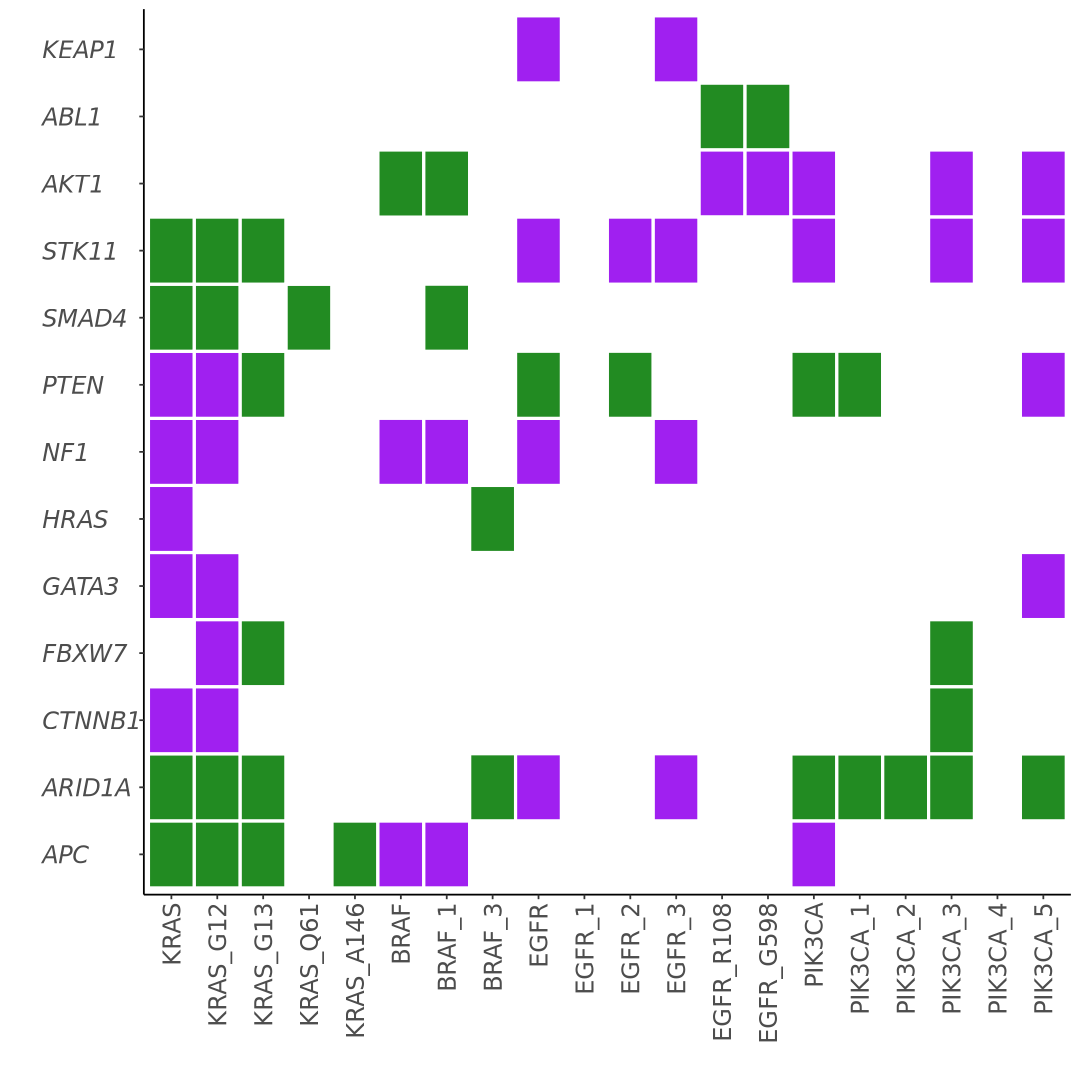

In [177]:
p

In [178]:
ggsave("../figures/468_hotspot_select_heatmap_plot.pdf", p, width = 9, height = 9)